# Building a Flight Price Prediction Model



#### **Importing Necessary Libraries**

In [1]:
!pip install flask
!pip install flask_ngrok pyngrok sentence-transformers

   ---------------------------------------- 0.0/12.0 MB ? eta -:--:--
   -------- ------------------------------- 2.6/12.0 MB 13.7 MB/s eta 0:00:01
   ------------------ --------------------- 5.5/12.0 MB 12.7 MB/s eta 0:00:01
   --------------------------- ------------ 8.4/12.0 MB 13.4 MB/s eta 0:00:01
   ---------------------------------------  11.8/12.0 MB 14.1 MB/s eta 0:00:01
   ---------------------------------------- 12.0/12.0 MB 13.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/566.1 kB ? eta -:--:--
   ---------------------------------------- 566.1/566.1 kB 8.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   -------------------------------------- - 2.6/2.7 MB 16.0 MB/s eta 0:00:01
   ---------------------------------------- 2.7/2.7 MB 11.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/113.8 MB ? eta -:--:--
   - -------------------------------------- 3.9/113.8 MB 19.7 MB/s eta 0:00:06
   -- --------

In [2]:
# !pip uninstall xgboost

In [3]:
# !pip install xgboost==1.6.2

In [ ]:
# !pip uninstall scikit-learn
# !pip install scikit-learn==1.2.2

In [2]:
!pip install blinker

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [4]:
import warnings
warnings.filterwarnings("ignore")

In [8]:
# pip install --force-reinstall --ignore-installed flask-ngrok

In [9]:
#### Do this later

# from pyngrok import ngrok
# from flask_ngrok import run_with_ngrok
# from flask import Flask, render_template, request, jsonify
# !ngrok authtoken "2lQehFbtavcCd2ux1ynNPHc4lJo_6Jzm1pDJiKyKvtMMfZnTu"

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


---
## **Data Loading**

In [5]:
# from google.colab import drive
# drive.mount('/content/drive')

In [6]:
flight_df=pd.read_csv("C:/Users/aimee/OneDrive/Documents/ML_Projects/Spl_Mod_1_MLOps/Data_Files/travel_capstone/flights.csv",on_bad_lines='skip')
hotel_df=pd.read_csv("C:/Users/aimee/OneDrive/Documents/ML_Projects/Spl_Mod_1_MLOps/Data_Files/travel_capstone/hotels.csv",on_bad_lines='skip')
user_df=pd.read_csv("C:/Users/aimee/OneDrive/Documents/ML_Projects/Spl_Mod_1_MLOps/Data_Files/travel_capstone/users.csv",on_bad_lines='skip')

In [7]:
flight_df.head()

,travelCode,userCode,from,to,flightType,price,time,distance,agency,date
0,0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,09/26/2019
1,0,0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,09/30/2019
2,1,0,Brasilia (DF),Florianopolis (SC),firstClass,1487.52,1.66,637.56,CloudFy,10/03/2019
3,1,0,Florianopolis (SC),Brasilia (DF),firstClass,1127.36,1.66,637.56,CloudFy,10/04/2019
4,2,0,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,10/10/2019


In [10]:
hotel_df.head()

,travelCode,userCode,name,place,days,price,total,date
0,0,0,Hotel A,Florianopolis (SC),4,313.02,1252.08,09/26/2019
1,2,0,Hotel K,Salvador (BH),2,263.41,526.82,10/10/2019
2,7,0,Hotel K,Salvador (BH),3,263.41,790.23,11/14/2019
3,11,0,Hotel K,Salvador (BH),4,263.41,1053.64,12/12/2019
4,13,0,Hotel A,Florianopolis (SC),1,313.02,313.02,12/26/2019


In [11]:
user_df.head()

,code,company,name,gender,age
0,0,4You,Roy Braun,male,21
1,1,4You,Joseph Holsten,male,37
2,2,4You,Wilma Mcinnis,female,48
3,3,4You,Paula Daniel,female,23
4,4,4You,Patricia Carson,female,44


---
## **Data Mining and Exploration**

#### **Dataset Shape**

In [8]:
# Shape of the dataset
df_list = [flight_df, hotel_df, user_df]
df_name_list = ['flight_df', 'hotel_df', 'user_df']

for df_name, df in zip(df_name_list, df_list):
    print(f'Total no. of rows and columns in {df_name}: {df.shape}')

Total no. of rows and columns in flight_df: (271888, 10)
Total no. of rows and columns in hotel_df: (40552, 8)
Total no. of rows and columns in user_df: (1340, 5)


#### **Dataset Info (Non-nulls + Data Type)**

In [9]:
# Dataset Info
for df_name, df in zip(df_name_list, df_list):
    print(f'{df_name} Dataset Info:-\n')
    print(df.info())
    print()

flight_df Dataset Info:-

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271888 entries, 0 to 271887
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   travelCode  271888 non-null  int64  
 1   userCode    271888 non-null  int64  
 2   from        271888 non-null  object 
 3   to          271888 non-null  object 
 4   flightType  271888 non-null  object 
 5   price       271888 non-null  float64
 6   time        271888 non-null  float64
 7   distance    271888 non-null  float64
 8   agency      271888 non-null  object 
 9   date        271888 non-null  object 
dtypes: float64(3), int64(2), object(5)
memory usage: 20.7+ MB
None

hotel_df Dataset Info:-

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40552 entries, 0 to 40551
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   travelCode  40552 non-null  int64  
 1   userCode    40552 non-null  i

#### **Summary Statistics for Numerical Columns**

In [12]:
# Summary statistics of numeric columns

for df_name, df in zip(df_name_list, df_list):
    print(f'{df_name} Dataset Summary Statistics:-\n')
    print(df.describe())
    print()

flight_df Dataset Summary Statistics:-

          travelCode       userCode         price           time  \
count  271888.000000  271888.000000  271888.00000  271888.000000   
mean    67971.500000     667.505495     957.37503       1.421147   
std     39243.724665     389.523127     362.31189       0.542541   
min         0.000000       0.000000     301.51000       0.440000   
25%     33985.750000     326.000000     672.66000       1.040000   
50%     67971.500000     659.000000     904.00000       1.460000   
75%    101957.250000    1011.000000    1222.24000       1.760000   
max    135943.000000    1339.000000    1754.17000       2.440000   

            distance  
count  271888.000000  
mean      546.955535  
std       208.851288  
min       168.220000  
25%       401.660000  
50%       562.140000  
75%       676.530000  
max       937.770000  

hotel_df Dataset Summary Statistics:-

          travelCode      userCode          days         price         total
count   40552.000000  4

#### **Summary Statistics for Categorical Columns**

In [13]:
# Summary statistics of categorical columns
for i, df in zip(df_name_list, df_list):
    print(f'{i} Dataset Summary Statistics:-\n')
    print(df.describe(include='object'))
    print()

flight_df Dataset Summary Statistics:-

                      from                  to  flightType   agency  \
count               271888              271888      271888   271888   
unique                   9                   9           3        3   
top     Florianopolis (SC)  Florianopolis (SC)  firstClass  Rainbow   
freq                 57317               57317      116418   116752   

              date  
count       271888  
unique         999  
top     09/26/2019  
freq          1335  

hotel_df Dataset Summary Statistics:-

           name          place        date
count     40552          40552       40552
unique        9              9         199
top     Hotel K  Salvador (BH)  10/03/2019
freq       5094           5094         404

user_df Dataset Summary Statistics:-

       company               name gender
count     1340               1340   1340
unique       5               1338      3
top       4You  Charlotte Johnson   male
freq       453                  2    452


#### **Missing Values**

In [15]:
# Check for Missing Values
for i, df in zip(df_name_list, df_list):
    print(f'Total no. of missing values in {i}:\n{df.isnull().sum()}\n')

Total no. of missing values in flight_df:
travelCode    0
userCode      0
from          0
to            0
flightType    0
price         0
time          0
distance      0
agency        0
date          0
dtype: int64

Total no. of missing values in hotel_df:
travelCode    0
userCode      0
name          0
place         0
days          0
price         0
total         0
date          0
dtype: int64

Total no. of missing values in user_df:
code       0
company    0
name       0
gender     0
age        0
dtype: int64



***There are no missing values in any of the datasets.***

#### **Duplicate Values**

In [16]:
# Check for Duplicate rows
for i, df in zip(df_name_list, df_list):
    print(f'Total no. of duplicate rows in {i}: {df.duplicated().sum()}')


Total no. of duplicate rows in flight_df: 0
Total no. of duplicate rows in hotel_df: 0
Total no. of duplicate rows in user_df: 0


***There are no duplicate values in any of the datasets.***

---
## **Data Preprocessing**

In [19]:
#flight_df1= flight_df.merge(user_df,how='outer',left_on='userCode',right_on='code')

In [17]:
# Converting date column data type into datetime
flight_df['date'] = pd.to_datetime(flight_df['date'])

# Extracting Weekday, Month, WeekNumber, Year, Day from date column
flight_df['week_day'] = flight_df['date'].dt.weekday
flight_df['month'] = flight_df['date'].dt.month
flight_df['week_no'] = flight_df['date'].dt.isocalendar().week
flight_df['year'] = flight_df['date'].dt.year
flight_df['day'] = flight_df['date'].dt.day

In [18]:
flight_df.head()

,travelCode,userCode,from,to,flightType,price,time,distance,agency,date,week_day,month,week_no,year,day
0,0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,2019-09-26,3,9,39,2019,26
1,0,0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,2019-09-30,0,9,40,2019,30
2,1,0,Brasilia (DF),Florianopolis (SC),firstClass,1487.52,1.66,637.56,CloudFy,2019-10-03,3,10,40,2019,3
3,1,0,Florianopolis (SC),Brasilia (DF),firstClass,1127.36,1.66,637.56,CloudFy,2019-10-04,4,10,40,2019,4
4,2,0,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,2019-10-10,3,10,41,2019,10


##### Filtering the dataframe based on relevant column

In [19]:
flights_filtered= flight_df[['from','to','flightType','agency','time','distance','week_day','week_no','day','month','year','price']]
flights_filtered.head()

,from,to,flightType,agency,time,distance,week_day,week_no,day,month,year,price
0,Recife (PE),Florianopolis (SC),firstClass,FlyingDrops,1.76,676.53,3,39,26,9,2019,1434.38
1,Florianopolis (SC),Recife (PE),firstClass,FlyingDrops,1.76,676.53,0,40,30,9,2019,1292.29
2,Brasilia (DF),Florianopolis (SC),firstClass,CloudFy,1.66,637.56,3,40,3,10,2019,1487.52
3,Florianopolis (SC),Brasilia (DF),firstClass,CloudFy,1.66,637.56,4,40,4,10,2019,1127.36
4,Aracaju (SE),Salvador (BH),firstClass,CloudFy,2.16,830.86,3,41,10,10,2019,1684.05


In [20]:
flights_filtered.shape

(271888, 12)

---
## **Exploratory Data Analysis (EDA)**

### **Univariate Analysis**

#### **Numerical Column Distribution**

Check for skewness in the distribution of numerical Columns

In [21]:
# Filter only numerical columns
numerical_columns = flights_filtered.select_dtypes(include=['number']).columns

# Calculate skewness for numerical columns
skewness = flights_filtered[numerical_columns].skew()

# Print skewness
print(skewness)


time       -0.179825
distance   -0.183944
week_day   -0.441701
week_no    -0.030191
day         0.006463
month      -0.039119
year        0.378661
price       0.313578
dtype: Float64


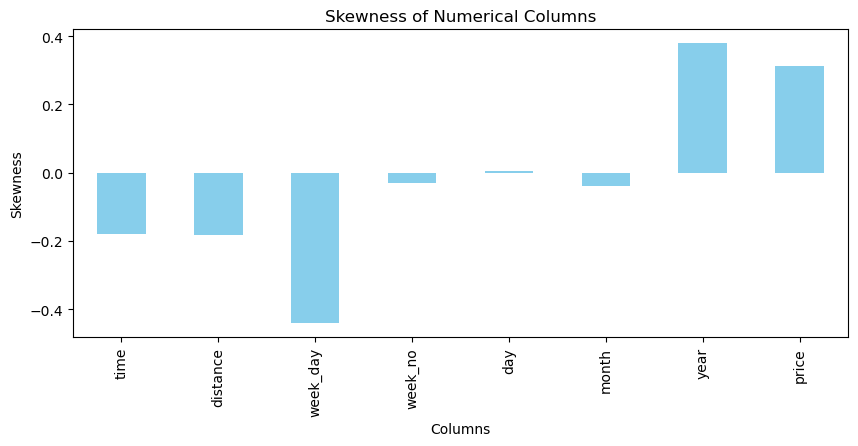

In [23]:
# Select numerical columns only
numerical_columns = flights_filtered.select_dtypes(include=['number']).columns

# Calculate skewness for numerical columns
skewness = flights_filtered[numerical_columns].skew()

# Plot skewness as a bar chart
skewness.plot(kind='bar', figsize=(10, 4), color='skyblue', title="Skewness of Numerical Columns")
plt.xlabel('Columns')
plt.ylabel('Skewness')
plt.show()



The **skewness value** helps us understand and check whether and which variables are normally distributed. The skewness value is generally interpreted as follows:

- The variables with skewness > 1 price are highly positively skewed: None
- The variables with skewness < -1 are highly negatively skewed: None
- The variables with 0.5 < skewness < 1 are moderately positively skewed: None
- The variables with -0.5 < skewness < -1 are moderately negatively skewed: None
- The variables with -0.5 < skewness < 0.5 are symmetric: All variables' skewness lies between -0.5 and +0.5.

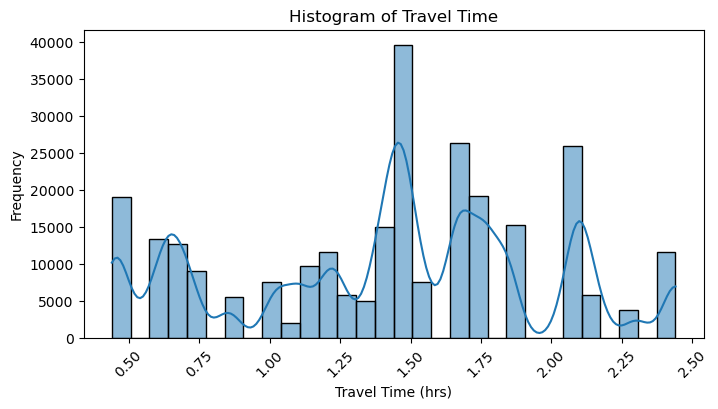

In [24]:
# Histogram with KDE of the 'time' column

plt.figure(figsize=(8, 4))
sns.histplot(flights_filtered['time'], bins=30, kde=True)
plt.title('Histogram of Travel Time')
plt.xlabel('Travel Time (hrs)')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()


**Observation:** Highest occurrence of travel time is 1.5 hours, followed by 1.75 and 2 hour flights.

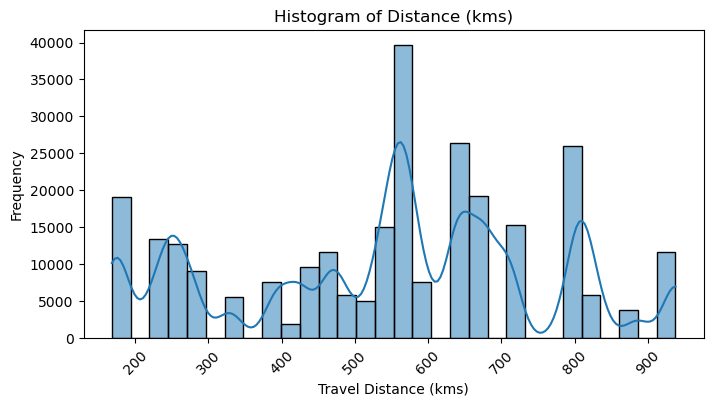

In [25]:
# Distribution of Distance 

plt.figure(figsize=(8, 4))
sns.histplot(flights_filtered['distance'], bins=30, kde=True)
plt.title('Histogram of Distance (kms)')
plt.xlabel('Travel Distance (kms)')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()


**Observation:** The distance travelled most frequently is ~550 kms and the range is generally of 550 - 800 kms.

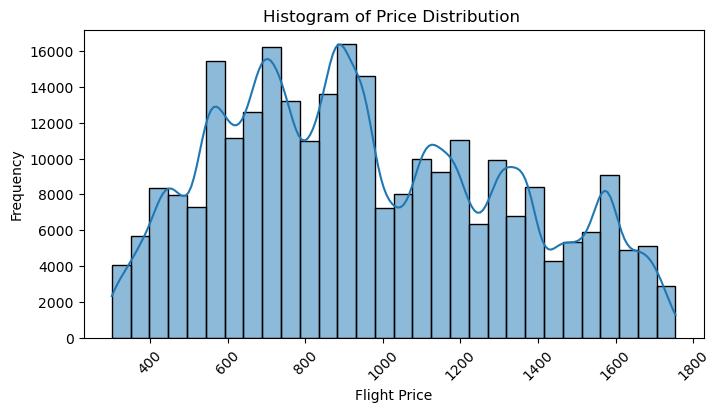

In [26]:
# Flight Price Distribution

plt.figure(figsize=(8, 4))
sns.histplot(flights_filtered['price'], bins=30, kde=True)
plt.title('Histogram of Price Distribution ')
plt.xlabel('Flight Price')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()


**Observation:**

The prices are distributed across a wide range, however, it can be observed that majority of bookings / flights have been in the lower range of 300 - 1000 while comparatively fewer bookings are > 1000. This information provides insights on the affordability and income levels of majority of the flyers.

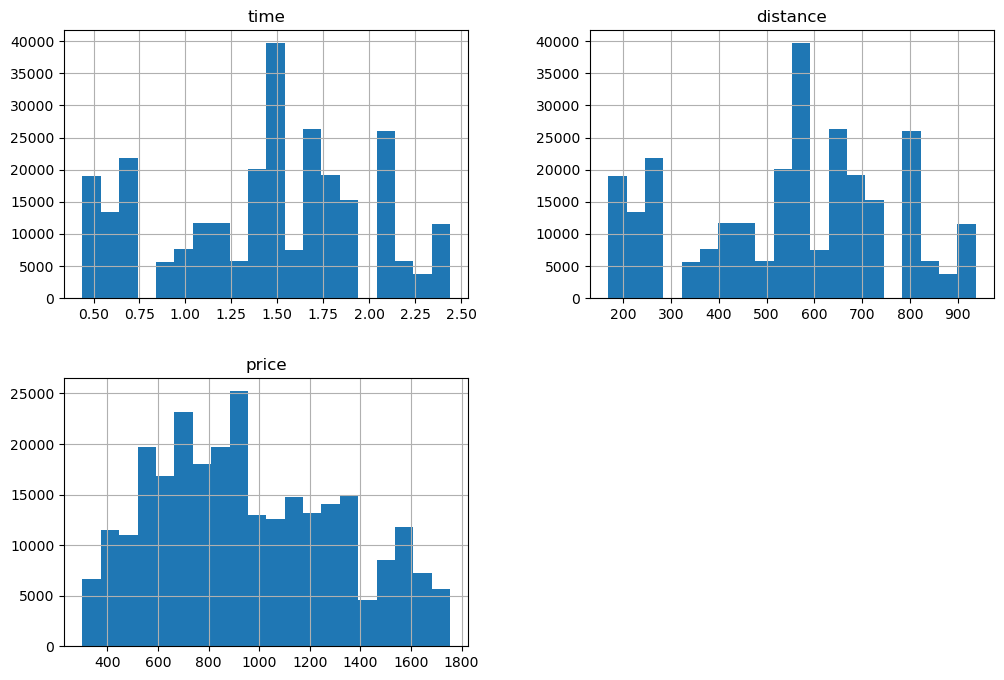

In [27]:
# Histograms of all numeric columns
numeric_cols = flights_filtered.select_dtypes(include=['int64', 'float64']).columns
flights_filtered[numeric_cols].hist(bins=20, figsize=(12, 8))
plt.show()

#### **Outlier detection in Numerical Coulmns using Box-plot**

If the distribution of numerical columns follows normal distribution, then use standard deviation to handle outliers.
Otherwise we will use IQR technique to handle outliers.

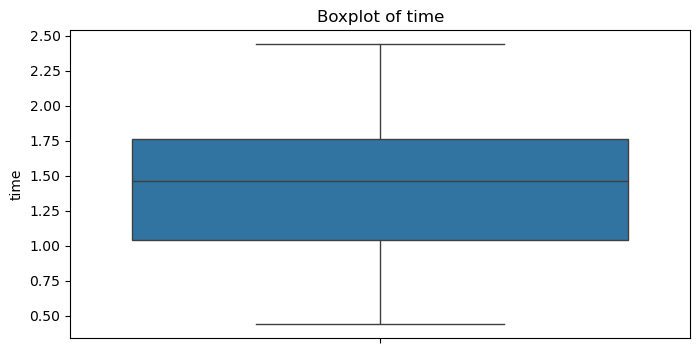

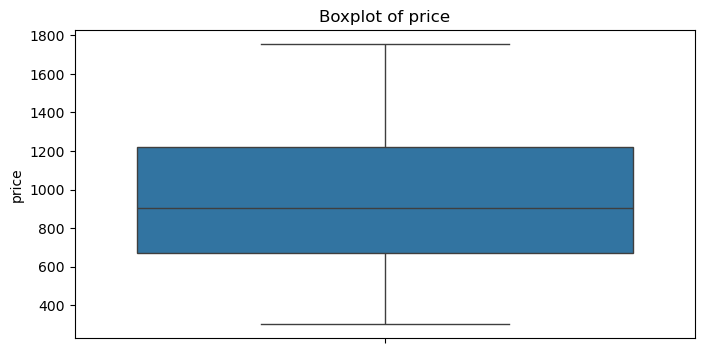

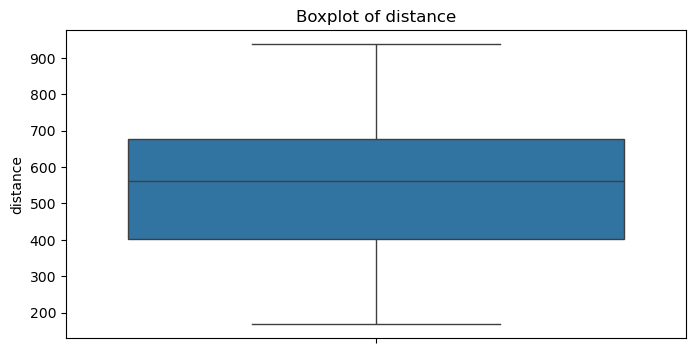

In [28]:
# Function to plot box plots
def plot_boxplot(data, column_name, figsize=(8, 4)):
    plt.figure(figsize=figsize)
    sns.boxplot(data=data[column_name])
    plt.xticks(rotation=45)
    plt.title(f'Boxplot of {column_name}')
    plt.show()

# Plot box plots for 'time','price','distance' columns
plot_boxplot(flights_filtered, 'time')
plot_boxplot(flights_filtered, 'price')
plot_boxplot(flights_filtered, 'distance')


**Observation:** No significant outliers detected in price, time and distance features.

#### **Distribution of Categorical Coulmns using Count-plot**

In [31]:
flights_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271888 entries, 0 to 271887
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   from        271888 non-null  object 
 1   to          271888 non-null  object 
 2   flightType  271888 non-null  object 
 3   agency      271888 non-null  object 
 4   time        271888 non-null  float64
 5   distance    271888 non-null  float64
 6   week_day    271888 non-null  int32  
 7   week_no     271888 non-null  UInt32 
 8   day         271888 non-null  int32  
 9   month       271888 non-null  int32  
 10  year        271888 non-null  int32  
 11  price       271888 non-null  float64
dtypes: UInt32(1), float64(3), int32(4), object(4)
memory usage: 20.0+ MB


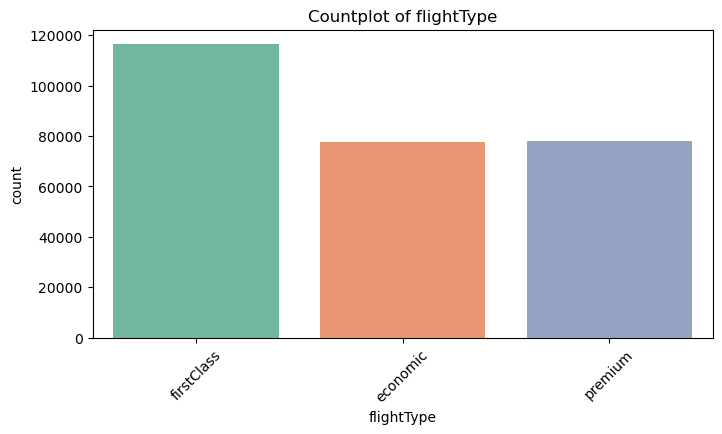

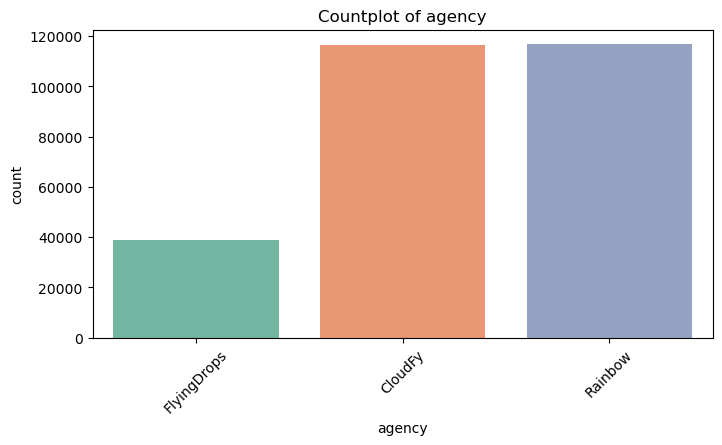

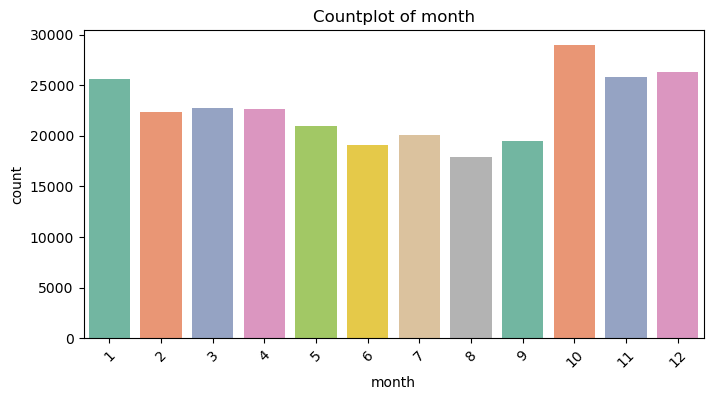

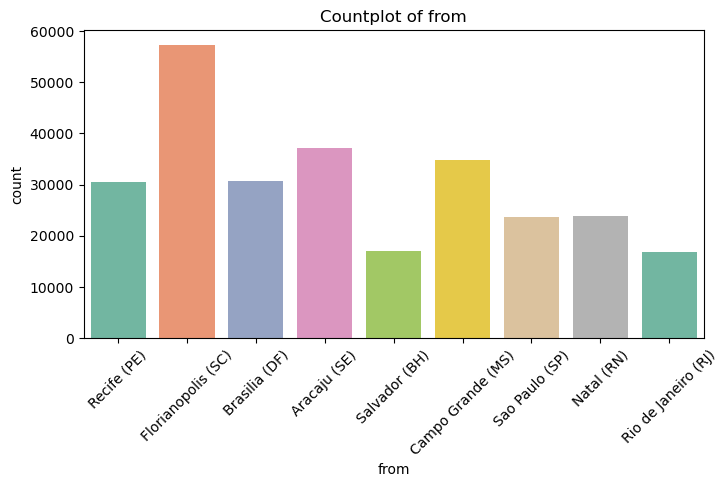

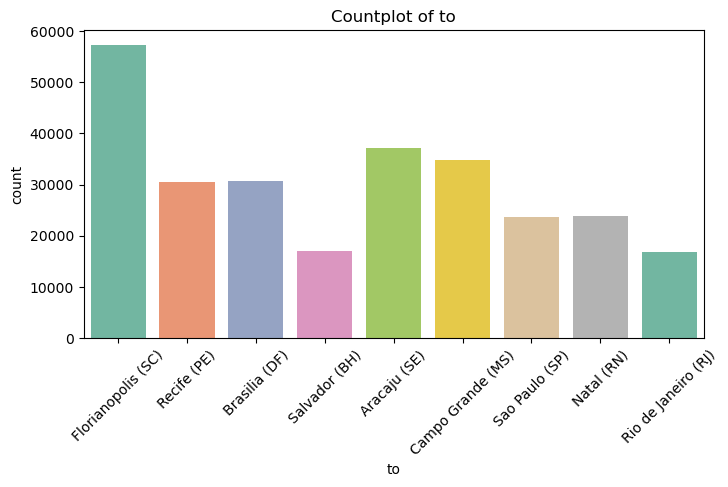

In [30]:
# List of columns to plot countplots for
columns_to_plot = ['flightType', 'agency', 'month', 'from', 'to']
data = [flights_filtered, flights_filtered, flights_filtered, flights_filtered, flights_filtered]  # Corresponding data for each plot

# Define a function to plot countplots
def plot_countplot(data, column_name, palette="Set2", figsize=(8, 4)):
    plt.figure(figsize=figsize)
    sns.countplot(x=column_name, data=data, palette=palette)
    plt.title(f'Countplot of {column_name}')
    plt.xticks(rotation=45)
    plt.show()

# Plot countplots for the specified columns
for col, df in zip(columns_to_plot, data):
    plot_countplot(df, col)


**Observation:**

- Flight type 'firstClass' has the highest bookings while 'economic' and 'premium' are about the same.
- 'CloundFy' and 'Rainbow' agencies have had the largest bookings and 'FlyingDrops' seems to be the last choice.
- Highest number of bookings have been in October and the peak travel period is October - January.
- The most famous 'to' and 'from' destination is 'Florianopolis (SC).

#### **Distribution of in Week Days and Year using a pie-chart**

week_day counts:
week_day
3    135944
0     34108
6     34088
4     33880
5     33868
Name: count, dtype: int64


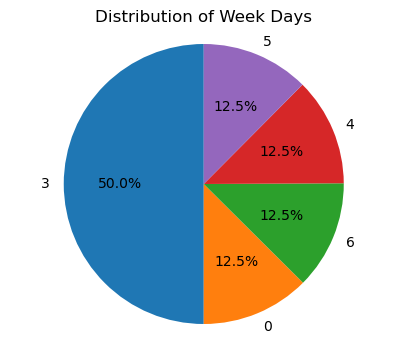

year counts:
year
2020    112571
2021     75363
2022     41761
2019     35826
2023      6367
Name: count, dtype: int64


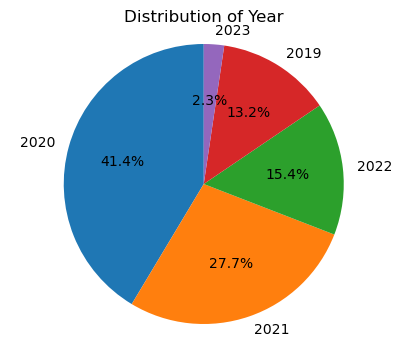

In [31]:
# Define a function to create and display pie charts
def plot_pie_chart(data, column_name, title, figsize=(5, 4)):
    counts = data[column_name].value_counts()
    print(f'{column_name} counts:\n{counts}')
    plt.figure(figsize=figsize)
    plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90)
    plt.title(title)
    plt.axis('equal')  # Ensures the pie chart is a circle
    plt.show()

# Plot pie charts for numerical columns with discrete values
plot_pie_chart(flights_filtered, 'week_day', 'Distribution of Week Days')
plot_pie_chart(flights_filtered, 'year', 'Distribution of Year')


**Observation**:

- About 50% of the flights have been on Thursday and the remaining 50% are equally distributed across Monday and Friday to Sunday.
- Surprisingly, highest number of flights have been in the year 2020 (even though it was the COVID year) followed by 2021, while fewer flights have been booked in 2019 and 2022-2023.

### **Bivariate Analysis**

#### **Relationship between independent numerical variables and target variable using Scatter Plot**

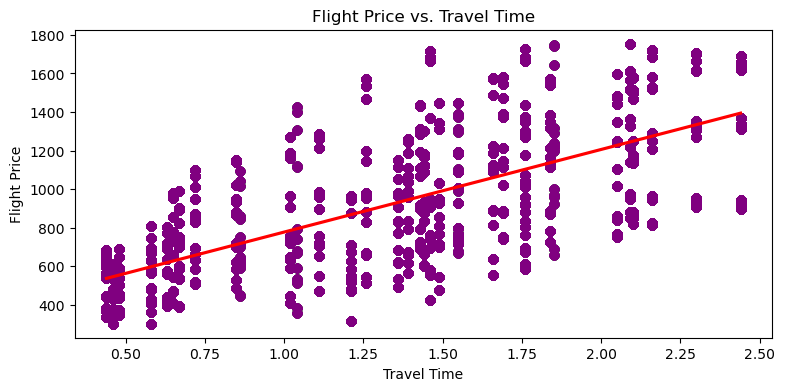

In [38]:
plt.figure(figsize=(9, 4))

sns.regplot(
    data=flights_filtered,
    x='time',
    y='price',
    scatter_kws={'color': 'purple', 'alpha': 0.3},
    line_kws={'color': 'red'}
)

plt.title('Flight Price vs. Travel Time')
plt.xlabel('Travel Time')
plt.ylabel('Flight Price')
plt.show()

**Observation:**

A clear upward trend can be observed in the 'travel time vs price' plot indicating that flight prices generally tend to higher for longer duration flights. (positive correlation)

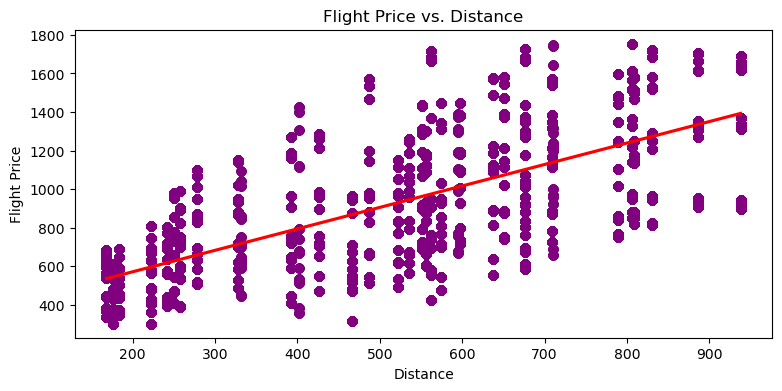

In [40]:
# Price vs. Travel Distance

plt.figure(figsize=(9, 4))

sns.regplot(
    data=flights_filtered,
    x='distance',
    y='price',
    scatter_kws={'color': 'purple', 'alpha': 0.3},
    line_kws={'color': 'red'}
)

plt.title('Flight Price vs. Distance')
plt.xlabel('Distance')
plt.ylabel('Flight Price')
plt.show()


**Observation:**

A clear upward trend can be observed in the 'distance vs price' plot indicating that flight prices generally tend to higher for long-distance flights. (positive correlation)

#### **Outliers in Categorical Columns using Box Plots**

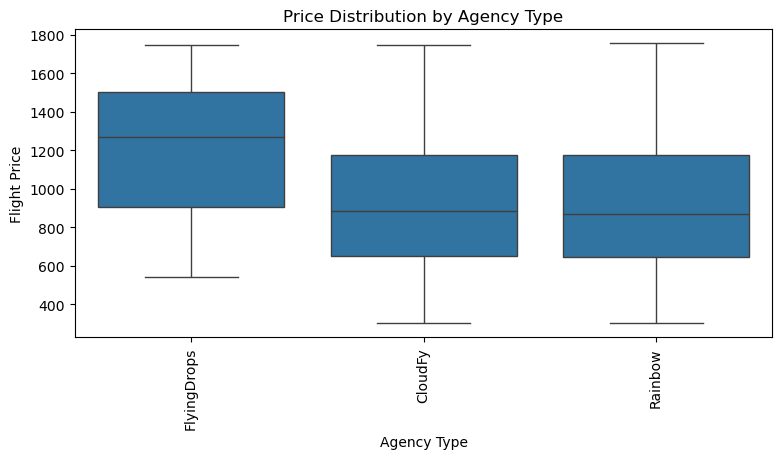

In [41]:
# Distribution of prices per agency type:

plt.figure(figsize=(9, 4))
sns.boxplot(data=flights_filtered, x='agency', y='price')
plt.xticks(rotation=90)
plt.xlabel('Agency Type')
plt.ylabel('Flight Price')
plt.title('Price Distribution by Agency Type')
plt.show()

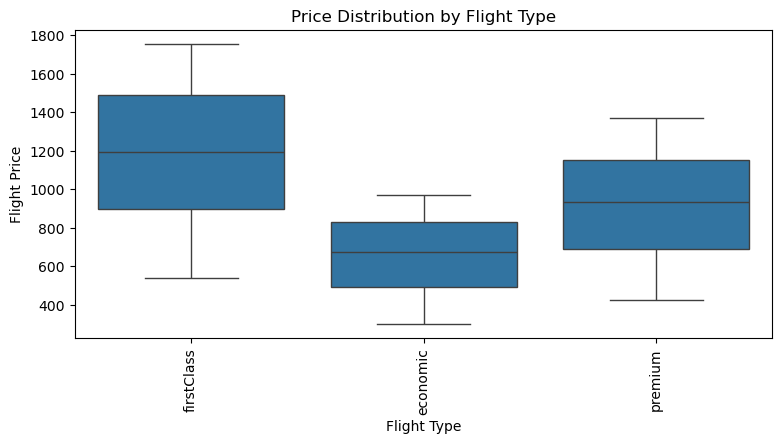

In [42]:
# Distribution of prices per Flight type:

plt.figure(figsize=(9, 4))
sns.boxplot(data=flights_filtered, x='flightType', y='price')
plt.xticks(rotation=90)
plt.xlabel('Flight Type')
plt.ylabel('Flight Price')
plt.title('Price Distribution by Flight Type')
plt.show()

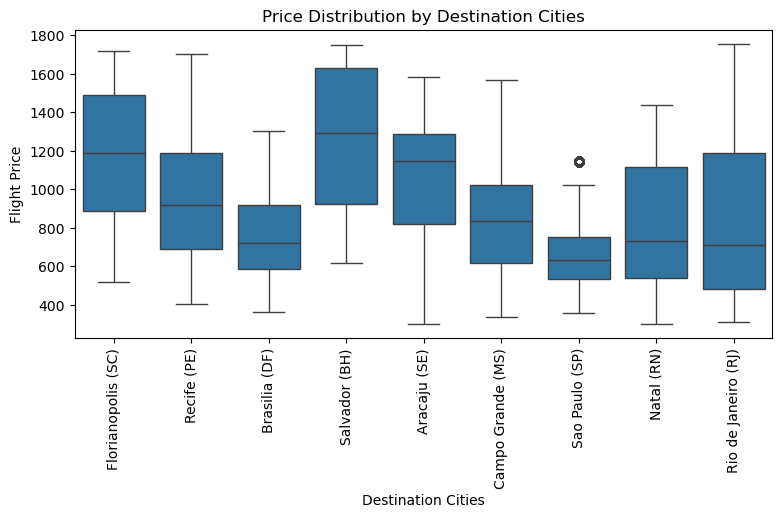

In [43]:
# Distribution of prices per Destination Cities:

plt.figure(figsize=(9, 4))
sns.boxplot(data=flights_filtered, x='to', y='price')
plt.xticks(rotation=90)
plt.xlabel('Destination Cities')
plt.ylabel('Flight Price')
plt.title('Price Distribution by Destination Cities')
plt.show()

**Observation**:

- **Variability**: Varying levels of price variability within different categories. Larger boxes indicate wider range of prices while smaller boxes indicate narrower ranges.

- **Outliers**: No signicant outliers are observed across any of the categories.

#### **Distribution of prices across categorical columns using Bar Plot**

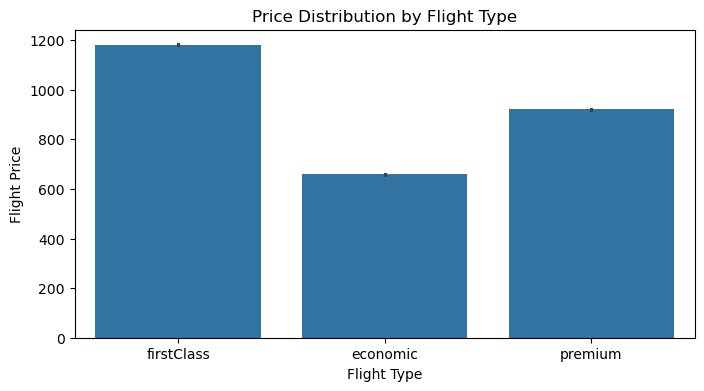

In [44]:
plt.figure(figsize=(8, 4))
sns.barplot(x='flightType',y='price', data=flights_filtered)
plt.xlabel('Flight Type')
plt.ylabel('Flight Price')
plt.title('Price Distribution by Flight Type')
plt.show()


**Observation:**

The most expensive flight Class Type is FirstClass, followed by Premium Class and Economic Class, as expected.

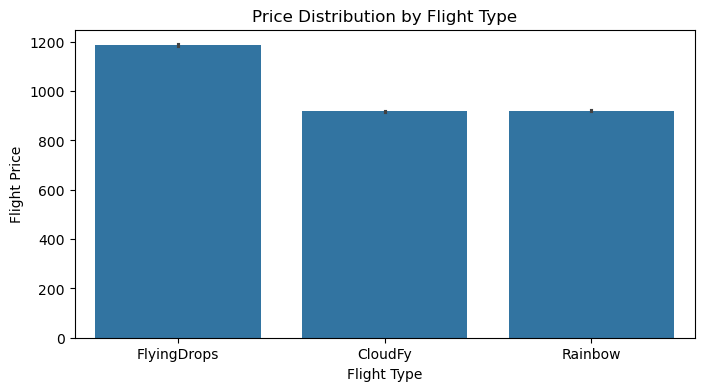

In [45]:
plt.figure(figsize=(8, 4))
sns.barplot(x='agency',y='price', data=flights_filtered)
plt.xlabel('Flight Type')
plt.ylabel('Flight Price')
plt.title('Price Distribution by Flight Type')
plt.show()


**Observation:**

The most expensive flight tickets agency was Flyingdrops, followed by Rainbow Class and Cloudfy agency. This also explains why FlyingDrops was the least preferred for booking flight tickets (as was seen in a bar plot above that FlyingDrops agency had the lowest number of flight bookings compared to the other two).

### **Multi-Variate Analysis**

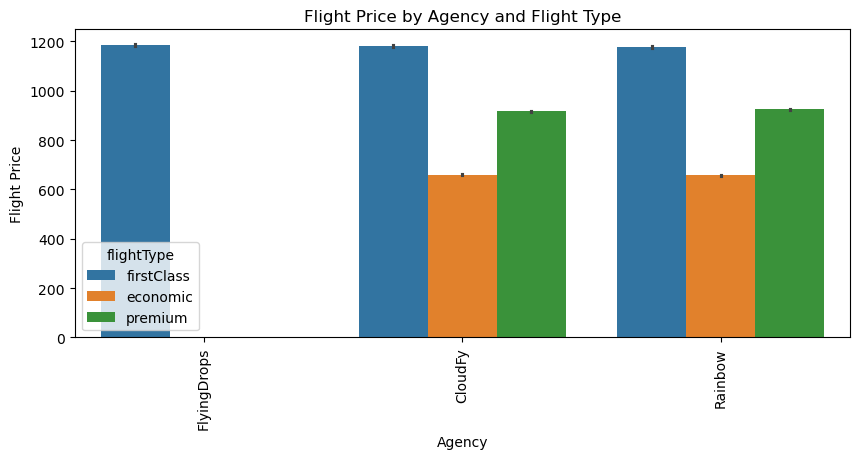

In [48]:
# Explore the relationship between the agency and flight types:

plt.figure(figsize=(10, 4))
sns.barplot(data=flights_filtered, x='agency', y='price', hue='flightType')
plt.xticks(rotation=90)
plt.xlabel('Agency')
plt.ylabel('Flight Price')
plt.title('Flight Price by Agency and Flight Type')
plt.show()

**Observation:**

Only FirstClass tickets were booked by FlyingDrops while the other 2 agencies were preferred for bookings of economic and premium classes.

---
## **Feature Engineering**

In [47]:
# renaming the Column name from "to" to "destination"
flights_filtered.rename(columns={"to":"destination"},inplace=True)

In [48]:
# Creating a new feature using distance and time columns
flights_filtered['flight_speed']=round(flights_filtered['distance']/flights_filtered['time'],2)

In [49]:
flights_filtered.head()

,from,destination,flightType,agency,time,distance,week_day,week_no,day,month,year,price,flight_speed
0,Recife (PE),Florianopolis (SC),firstClass,FlyingDrops,1.76,676.53,3,39,26,9,2019,1434.38,384.39
1,Florianopolis (SC),Recife (PE),firstClass,FlyingDrops,1.76,676.53,0,40,30,9,2019,1292.29,384.39
2,Brasilia (DF),Florianopolis (SC),firstClass,CloudFy,1.66,637.56,3,40,3,10,2019,1487.52,384.07
3,Florianopolis (SC),Brasilia (DF),firstClass,CloudFy,1.66,637.56,4,40,4,10,2019,1127.36,384.07
4,Aracaju (SE),Salvador (BH),firstClass,CloudFy,2.16,830.86,3,41,10,10,2019,1684.05,384.66


### Now we are checking for outliers in flight_speed column by using Box_plot

<Axes: xlabel='flight_speed'>

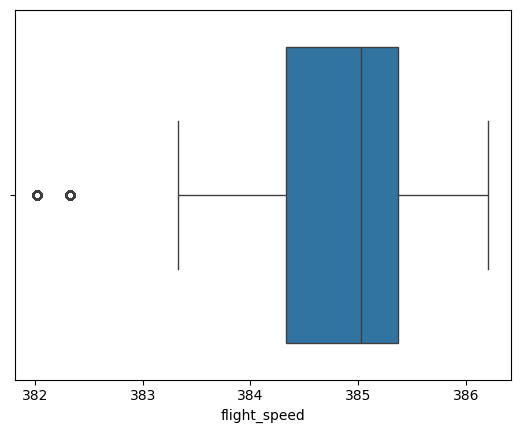

In [50]:
sns.boxplot(x=flights_filtered['flight_speed'])

We can see there are few outliers.

### Checking outliers using IQR method

In [51]:
Q1= np.percentile(flights_filtered['flight_speed'],25)
Q3= np.percentile(flights_filtered['flight_speed'],75)
IQR= Q3-Q1

In [52]:
lower_bound= Q1-IQR*1.5
upper_bound= Q3+IQR*1.5
print(lower_bound,upper_bound)

382.77 386.93000000000006



Here's a revised explanation with the updated perspective on the outliers in the distribution of the flight speed column:

The distribution of the flight speed column in the above graph appears to be left-skewed, with outliers visible in the box plot below the flight speed of 383 km/hr. However, these data points should not be treated as outliers in this case.

Upon closer inspection, these speeds likely occurred due to bad weather conditions, which are valid real-world scenarios affecting flight speeds. Instead of removing or imputing these values, they should be retained for analysis, as they can provide critical insights into how external factors influence flight operations.

To further investigate, additional context such as weather data or flight logs could help confirm the reasoning behind these reduced speeds and support better decision-making for operational improvements.

In [53]:
df=flights_filtered.copy()
df.describe()

,time,distance,week_day,week_no,day,month,year,price,flight_speed
count,271888.000000,271888.000000,271888.000000,271888.0,271888.000000,271888.000000,271888.000000,271888.00000,271888.000000
mean,1.421147,546.955535,3.373521,27.04532,15.790458,6.607519,2020.522862,957.37503,384.785156
std,0.542541,208.851288,1.655530,15.793449,8.826961,3.606611,0.980161,362.31189,0.850795
min,0.440000,168.220000,0.000000,1.0,1.000000,1.000000,2019.000000,301.51000,382.020000
25%,1.040000,401.660000,3.000000,13.0,8.000000,3.000000,2020.000000,672.66000,384.330000
50%,1.460000,562.140000,3.000000,27.0,16.000000,7.000000,2020.000000,904.00000,385.030000
75%,1.760000,676.530000,4.000000,42.0,24.000000,10.000000,2021.000000,1222.24000,385.370000
max,2.440000,937.770000,6.000000,53.0,31.000000,12.000000,2023.000000,1754.17000,386.210000


In [54]:
flights_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271888 entries, 0 to 271887
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   from          271888 non-null  object 
 1   destination   271888 non-null  object 
 2   flightType    271888 non-null  object 
 3   agency        271888 non-null  object 
 4   time          271888 non-null  float64
 5   distance      271888 non-null  float64
 6   week_day      271888 non-null  int32  
 7   week_no       271888 non-null  UInt32 
 8   day           271888 non-null  int32  
 9   month         271888 non-null  int32  
 10  year          271888 non-null  int32  
 11  price         271888 non-null  float64
 12  flight_speed  271888 non-null  float64
dtypes: UInt32(1), float64(4), int32(4), object(4)
memory usage: 22.0+ MB


**One-hot encoding**

In [55]:
# Apply one-hot encoding to specific categorical columns
df = pd.get_dummies(
    df,
    columns=['from', 'destination', 'flightType', 'agency'],
    prefix=['from', 'destination', 'flightType', 'agency']
)

# Display the first few rows of the transformed DataFrame
df.head()


,time,distance,week_day,week_no,day,month,year,price,flight_speed,from_Aracaju (SE),...,destination_Recife (PE),destination_Rio de Janeiro (RJ),destination_Salvador (BH),destination_Sao Paulo (SP),flightType_economic,flightType_firstClass,flightType_premium,agency_CloudFy,agency_FlyingDrops,agency_Rainbow
0,1.76,676.53,3,39,26,9,2019,1434.38,384.39,False,...,False,False,False,False,False,True,False,False,True,False
1,1.76,676.53,0,40,30,9,2019,1292.29,384.39,False,...,True,False,False,False,False,True,False,False,True,False
2,1.66,637.56,3,40,3,10,2019,1487.52,384.07,False,...,False,False,False,False,False,True,False,True,False,False
3,1.66,637.56,4,40,4,10,2019,1127.36,384.07,False,...,False,False,False,False,False,True,False,True,False,False
4,2.16,830.86,3,41,10,10,2019,1684.05,384.66,True,...,False,False,True,False,False,True,False,True,False,False


In [56]:
df.shape

(271888, 33)



# **Feature Selection**

##**Feature Selection Using Statistical Test ANNOVA F-Test**

In [57]:
final_df1=df

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271888 entries, 0 to 271887
Data columns (total 33 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   time                             271888 non-null  float64
 1   distance                         271888 non-null  float64
 2   week_day                         271888 non-null  int32  
 3   week_no                          271888 non-null  UInt32 
 4   day                              271888 non-null  int32  
 5   month                            271888 non-null  int32  
 6   year                             271888 non-null  int32  
 7   price                            271888 non-null  float64
 8   flight_speed                     271888 non-null  float64
 9   from_Aracaju (SE)                271888 non-null  bool   
 10  from_Brasilia (DF)               271888 non-null  bool   
 11  from_Campo Grande (MS)           271888 non-null  bool   
 12  fr

In [59]:
final_df1= df.drop(columns=['time','flight_speed','month','year','distance'],axis=1)

In [60]:
import pandas as pd
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

# Assuming df is your DataFrame with features and target variable 'target'

# Separate features (X) and target variable (y)
X = final_df1.drop('price', axis=1)  # Features
y = final_df1['price']                # Target variable

# Get the numerical features in X
num_features = X.select_dtypes(include=['number']).columns

# If the number of features is less than k, adjust k to the number of available features
k = min(27, len(num_features))  # Ensure k doesn't exceed the number of available features

# ANOVA F-test for numerical features
f_selector = SelectKBest(score_func=f_classif, k=k)
f_selector.fit(X[num_features], y)

# Get indices of top k features
numerical_top_indices = f_selector.get_support(indices=True)

# Combine top indices
top_indices = list(numerical_top_indices)

# Get top k feature names
top_features = X.columns[top_indices]

# Display top k features
print("Top k selected features:")
print(top_features)


Top k selected features:
Index(['week_day', 'week_no', 'day'], dtype='object')


In [61]:
!pip install statsmodels

In [62]:
#Multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np

# Define the function to calculate VIF
def calc_vif(df):
    vif_data = pd.DataFrame()
    vif_data["Feature"] = df.columns
    vif_data["VIF"] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
    return vif_data

# Filter numerical columns excluding boolean columns
numerical_columns = flights_filtered.select_dtypes(include=[np.number]).columns

# List of valid numerical columns
valid_columns = ['time', 'distance', 'week_day', 'week_no', 'day', 'month', 'year', 'price', 'flight_speed']

# Ensure all valid columns are numerical
filtered_df = flights_filtered[valid_columns]

# Convert 'UInt32' columns to float64
if 'week_no' in filtered_df.columns:
    filtered_df['week_no'] = filtered_df['week_no'].astype(float)

# Drop any constant or low-variance columns
filtered_df = filtered_df.loc[:, (filtered_df.var() > 0)]

# Check for any missing or infinite values
filtered_df = filtered_df.replace([np.inf, -np.inf], np.nan).dropna()

# Debugging: Inspect the filtered DataFrame
print("Filtered DataFrame Info:")
print(filtered_df.info())

# Calculate VIF
try:
    vif_result = calc_vif(filtered_df)
    print(vif_result)
except Exception as e:
    print(f"Error calculating VIF: {e}")

Filtered DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271888 entries, 0 to 271887
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   time          271888 non-null  float64
 1   distance      271888 non-null  float64
 2   week_day      271888 non-null  int32  
 3   week_no       271888 non-null  float64
 4   day           271888 non-null  int32  
 5   month         271888 non-null  int32  
 6   year          271888 non-null  int32  
 7   price         271888 non-null  float64
 8   flight_speed  271888 non-null  float64
dtypes: float64(5), int32(4)
memory usage: 14.5 MB
None
        Feature           VIF
0          time  1.546121e+06
1      distance  1.548498e+06
2      week_day  5.160073e+00
3       week_no  7.255121e+01
4           day  4.427838e+00
5         month  8.001092e+01
6          year  7.911799e+05
7         price  1.362082e+01
8  flight_speed  7.937973e+05


In [63]:
X.rename(columns={'from_Sao Paulo (SP)':'from_Sao_Paulo (SP)','from_Rio de Janeiro (RJ)':'from_Rio_de_Janeiro (RJ)','from_Campo Grande (MS)':'from_Campo_Grande (MS)',
                                  'destination_Sao Paulo (SP)':'destination_Sao_Paulo (SP)','destination_Rio de Janeiro (RJ)':'destination_Rio_de_Janeiro (RJ)','destination_Campo Grande (MS)':'destination_Campo_Grande (MS)'},inplace=True)

In [64]:
features_ordering=['from_Florianopolis (SC)',
 'from_Sao_Paulo (SP)',
 'from_Salvador (BH)',
 'from_Brasilia (DF)',
 'from_Rio_de_Janeiro (RJ)',
 'from_Campo_Grande (MS)',
 'from_Aracaju (SE)',
 'from_Natal (RN)',
 'from_Recife (PE)',
 'destination_Florianopolis (SC)',
 'destination_Sao_Paulo (SP)',
 'destination_Salvador (BH)',
 'destination_Brasilia (DF)',
 'destination_Rio_de_Janeiro (RJ)',
 'destination_Campo_Grande (MS)',
 'destination_Aracaju (SE)',
 'destination_Natal (RN)',
 'destination_Recife (PE)',
 'flightType_economic',
 'flightType_firstClass',
 'flightType_premium',
 'agency_Rainbow',
 'agency_CloudFy',
 'agency_FlyingDrops',
 'week_no',
 'week_day']

In [65]:
#Ordering features based on flask output
final_features= X[features_ordering]

In [66]:
X1= final_features

# Target variable
y1 = y

# Split the data into training and testing sets
X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size=0.2, random_state=42)

scaler_new = StandardScaler()

X_train1 = scaler_new.fit_transform(X_train1)
X_test1 = scaler_new.transform(X_test1)


In [67]:
final_features.columns

Index(['from_Florianopolis (SC)', 'from_Sao_Paulo (SP)', 'from_Salvador (BH)',
       'from_Brasilia (DF)', 'from_Rio_de_Janeiro (RJ)',
       'from_Campo_Grande (MS)', 'from_Aracaju (SE)', 'from_Natal (RN)',
       'from_Recife (PE)', 'destination_Florianopolis (SC)',
       'destination_Sao_Paulo (SP)', 'destination_Salvador (BH)',
       'destination_Brasilia (DF)', 'destination_Rio_de_Janeiro (RJ)',
       'destination_Campo_Grande (MS)', 'destination_Aracaju (SE)',
       'destination_Natal (RN)', 'destination_Recife (PE)',
       'flightType_economic', 'flightType_firstClass', 'flightType_premium',
       'agency_Rainbow', 'agency_CloudFy', 'agency_FlyingDrops', 'week_no',
       'week_day'],
      dtype='object')

#**Model Building, Training, Cross-Validation, Hyperparameter Tuning & Evaluation**

##**Linear Regression**

###**Baseline Model**

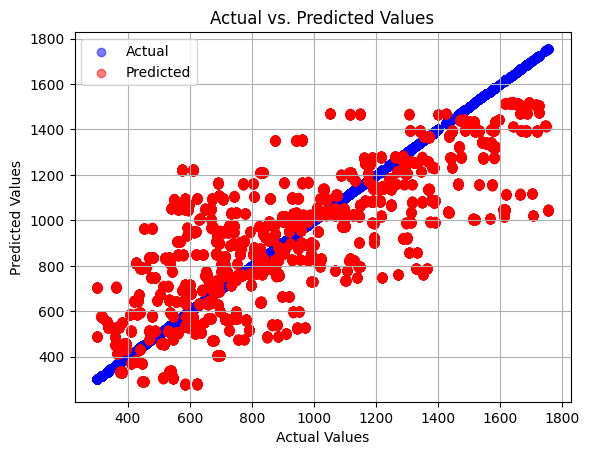

In [68]:
# Create and train the Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train1, y_train1)

# Make predictions on the test set
y_pred1 = linear_model.predict(X_test1)

# Evaluate the model
mae_lr = mean_absolute_error(y_test1, y_pred1)
mse_lr = mean_squared_error(y_test1, y_pred1)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test1, y_pred1)

# Calculate adjusted R-squared for linear regression
n = X_test1.shape[0]
p = X_test1.shape[1]


# Calculate adjusted R-squared
adj_r2_lr = 1 - ((1 - r2_lr) * (n - 1) / (n - p - 1))


plt.scatter(y_test1, y_test1, c='b', label='Actual', alpha=0.5)  # Blue for actual
plt.scatter(y_test1, y_pred1, c='r', label='Predicted', alpha=0.5)  # Red for predicted
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values")
plt.legend(loc='upper left')
plt.grid(True)
plt.show()



###**Model Evaluation**

In [69]:
model_result = pd.DataFrame([['Linear Regression Baseline', mse_lr,rmse_lr,mae_lr, r2_lr,adj_r2_lr]],
               columns = ['Model', 'MSE', 'RMSE', 'MAE', 'R2','adj_r2'])

model_result

,Model,MSE,RMSE,MAE,R2,adj_r2
0,Linear Regression Baseline,47085.142024,216.99111,165.921843,0.64267,0.642499


###**Hyperparameter Tuning Linear**

In [70]:
# Define hyperparameters and their potential values
param_grid_linear = {
    'fit_intercept': [True, False],
    'positive': [True, False]
}

# Create a GridSearchCV object for Linear Regression
grid_lr = GridSearchCV(linear_model, param_grid_linear, cv=3, scoring='neg_mean_squared_error')
grid_lr.fit(X_train1, y_train1)

# Get the best hyperparameters for Linear Regression
best_linear_reg = grid_lr.best_estimator_

# Perform grid search
best_linear_reg.fit(X_train1, y_train1)



LinearRegression()

In [71]:
# Print the best hyperparameters
print("Best Hyperparameters for Linear Regression:", grid_lr.best_estimator_)

Best Hyperparameters for Linear Regression: LinearRegression()


### **Model Evaluation**

In [72]:
# Evaluate the model
y_pred_linear_tuned = best_linear_reg.predict(X_test1)

mae_linear_tuned = mean_absolute_error(y_test1, y_pred_linear_tuned )
mse_linear_tuned = mean_squared_error(y_test1, y_pred_linear_tuned )
rmse_linear_tuned = np.sqrt(mse_linear_tuned)
r2_linear_tuned = r2_score(y_test1, y_pred_linear_tuned )
adj_r2_linear_tuned = 1 - ((1 - r2_linear_tuned) * (n - 1) / (n - p - 1))

model = pd.DataFrame([['Linear Regression Tuned',  mse_linear_tuned,rmse_linear_tuned,mae_linear_tuned, r2_linear_tuned,adj_r2_linear_tuned]],
               columns = ['Model', 'MSE', 'RMSE', 'MAE', 'R2','adj_r2'])

model_result = pd.concat([model_result,model],axis=0,ignore_index = True)
model_result

,Model,MSE,RMSE,MAE,R2,adj_r2
0,Linear Regression Baseline,47085.142024,216.99111,165.921843,0.64267,0.642499
1,Linear Regression Tuned,47085.142024,216.99111,165.921843,0.64267,0.642499


##**Lasso Regression**

###**Baseline Model**

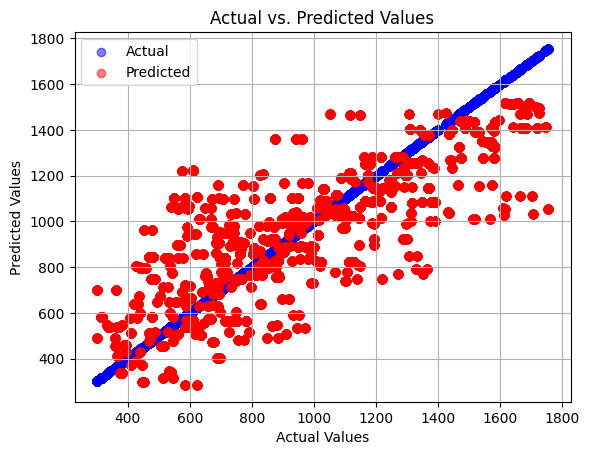

In [73]:
from sklearn.linear_model import Lasso
# Basic Lasso Regression
lasso_model = Lasso()  # You can adjust the alpha parameter for regularization strength
lasso_model.fit(X_train1, y_train1)

# Evaluate the model
y_pred_lasso = lasso_model.predict(X_test1)

mae_lasso = mean_absolute_error(y_test1, y_pred_lasso)
mse_lasso = mean_squared_error(y_test1, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y_test1, y_pred_lasso)
adj_r2_lasso = 1 - ((1 - r2_lasso) * (n - 1) / (n - p - 1))

plt.scatter(y_test1, y_test1, c='b', label='Actual', alpha=0.5)  # Blue for actual
plt.scatter(y_test1, y_pred_lasso, c='r', label='Predicted', alpha=0.5)  # Red for predicted
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values")
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

### **Model Evaluation**

In [74]:
model = pd.DataFrame([['Lasso Regression Baseline',  mse_lasso,rmse_lasso,mae_lasso, r2_lasso,adj_r2_lasso]],
               columns = ['Model', 'MSE', 'RMSE', 'MAE', 'R2','adj_r2'])

model_result = pd.concat([model_result,model],axis=0,ignore_index = True)
model_result

,Model,MSE,RMSE,MAE,R2,adj_r2
0,Linear Regression Baseline,47085.142024,216.991110,165.921843,0.642670,0.642499
1,Linear Regression Tuned,47085.142024,216.991110,165.921843,0.642670,0.642499
2,Lasso Regression Baseline,47030.031372,216.864085,165.627060,0.643088,0.642917


###**Hyperparameter Tuning Lasso**

In [75]:
# Hyperparameter tuning using GridSearchCV
from sklearn.model_selection import GridSearchCV

# Define hyperparameters and their potential values
param_grid = {
    'alpha': [0.001,0.01, 0.1,0.3,0.5,0.6,0.8, 1.0,10]  # Adjust the range of alpha values as needed
}

# Create a GridSearchCV object for Lasso Regression
grid_search_lasso = GridSearchCV(lasso_model, param_grid, cv=3, scoring='neg_mean_squared_error')

# Perform grid search
grid_search_lasso.fit(X_train1, y_train1)

# Get the best hyperparameters for Lasso Regression
best_lasso_model = grid_search_lasso.best_estimator_

# Fit the best model to the training data
best_lasso_model.fit(X_train1, y_train1)

Lasso(alpha=0.01)

In [76]:
# Print the best hyperparameters
print("Best Hyperparameters for Lasso Regression:", grid_search_lasso.best_params_)

Best Hyperparameters for Lasso Regression: {'alpha': 0.01}


### **Model Evaluation**

In [77]:
# Evaluate the model
y_pred_lasso_tuned = best_lasso_model.predict(X_test1)

mae_lasso_tuned = mean_absolute_error(y_test1, y_pred_lasso_tuned )
mse_lasso_tuned = mean_squared_error(y_test1, y_pred_lasso_tuned )
rmse_lasso_tuned = np.sqrt(mse_lasso_tuned)
r2_lasso_tuned = r2_score(y_test1, y_pred_lasso_tuned )
adj_r2_lasso_tuned = 1 - ((1 - r2_lasso_tuned) * (n - 1) / (n - p - 1))

model = pd.DataFrame([['Lasso Regression Tuned',  mse_lasso_tuned,rmse_lasso_tuned,mae_lasso_tuned, r2_lasso_tuned,adj_r2_lasso_tuned]],
               columns = ['Model', 'MSE', 'RMSE', 'MAE', 'R2','adj_r2'])

model_result = pd.concat([model_result,model],axis=0,ignore_index = True)
model_result

,Model,MSE,RMSE,MAE,R2,adj_r2
0,Linear Regression Baseline,47085.142024,216.991110,165.921843,0.642670,0.642499
1,Linear Regression Tuned,47085.142024,216.991110,165.921843,0.642670,0.642499
2,Lasso Regression Baseline,47030.031372,216.864085,165.627060,0.643088,0.642917
3,Lasso Regression Tuned,47023.319846,216.848610,165.357816,0.643139,0.642968


##**Ridge Regression**

###**Baseline Model**

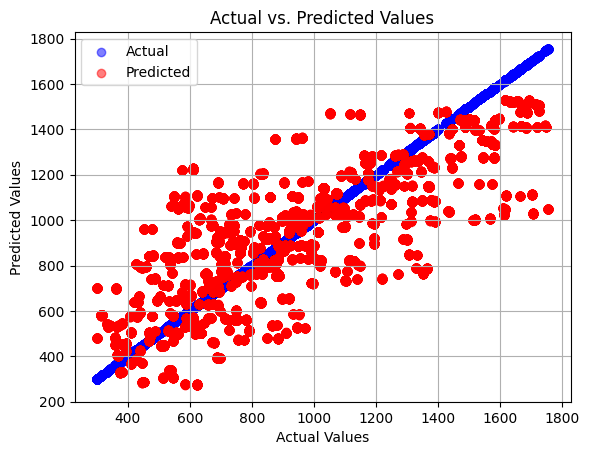

In [78]:
from sklearn.linear_model import Ridge

# Basic Ridge Regression
ridge_model = Ridge()  # You can adjust the alpha parameter for regularization strength
ridge_model.fit(X_train1, y_train1)

# Evaluate the model
y_pred_ridge = ridge_model.predict(X_test1)

mae_ridge = mean_absolute_error(y_test1, y_pred_ridge)
mse_ridge = mean_squared_error(y_test1,y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test1, y_pred_ridge)
adj_r2_ridge = 1 - ((1 - r2_ridge) * (n - 1) / (n - p - 1))

plt.scatter(y_test1, y_test1, c='b', label='Actual', alpha=0.5)  # Blue for actual
plt.scatter(y_test1, y_pred_ridge, c='r', label='Predicted', alpha=0.5)  # Red for predicted
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values")
plt.legend(loc='upper left')
plt.grid(True)
plt.show()



### **Model Evaluation**

In [79]:
model = pd.DataFrame([['Ridge Regression Baseline',  mse_ridge,rmse_ridge,mae_ridge, r2_ridge,adj_r2_ridge]],
               columns = ['Model', 'MSE', 'RMSE', 'MAE', 'R2','adj_r2'])

model_result = pd.concat([model_result,model],axis=0,ignore_index = True)
model_result

,Model,MSE,RMSE,MAE,R2,adj_r2
0,Linear Regression Baseline,47085.142024,216.991110,165.921843,0.642670,0.642499
1,Linear Regression Tuned,47085.142024,216.991110,165.921843,0.642670,0.642499
2,Lasso Regression Baseline,47030.031372,216.864085,165.627060,0.643088,0.642917
3,Lasso Regression Tuned,47023.319846,216.848610,165.357816,0.643139,0.642968
4,Ridge Regression Baseline,47023.430658,216.848866,165.355628,0.643138,0.642967


###**Hyperparameter Tuning Ridge**

In [80]:
# Hyperparameter tuning using GridSearchCV
param_grid = {
    'alpha': [0.001,0.01, 0.1,0.3,0.5,0.6,0.8, 1.0,10,20,50]  # Adjust the range of alpha values as needed
}


# Create a GridSearchCV object for Ridge Regression
grid_search_ridge = GridSearchCV(ridge_model, param_grid, cv=3, scoring='neg_mean_squared_error')

grid_search_ridge.fit(X_train1, y_train1)

# Get the best hyperparameters for Ridge Regression
best_ridge_model = grid_search_ridge.best_estimator_

# Perform grid search
best_ridge_model.fit(X_train1, y_train1)

Ridge(alpha=20)

In [81]:
# Print the best hyperparameters
print("Best Hyperparameters for Ridge Regression:", grid_search_ridge.best_estimator_)

Best Hyperparameters for Ridge Regression: Ridge(alpha=20)


### **Model Evaluation**

In [82]:
# Evaluate the model
y_pred_ridge_tuned = best_ridge_model.predict(X_test1)

mae_ridge_tuned = mean_absolute_error(y_test1, y_pred_ridge_tuned )
mse_ridge_tuned = mean_squared_error(y_test1, y_pred_ridge_tuned )
rmse_ridge_tuned = np.sqrt(mse_ridge_tuned)
r2_ridge_tuned = r2_score(y_test1, y_pred_ridge_tuned )
adj_r2_ridge_tuned = 1 - ((1 - r2_ridge_tuned) * (n - 1) / (n - p - 1))

model = pd.DataFrame([['Ridge Regression Tuned',  mse_ridge_tuned,rmse_ridge_tuned,mae_ridge_tuned, r2_ridge_tuned,adj_r2_ridge_tuned]],
               columns = ['Model', 'MSE', 'RMSE', 'MAE', 'R2','adj_r2'])

model_result = pd.concat([model_result,model],axis=0,ignore_index = True)
model_result

,Model,MSE,RMSE,MAE,R2,adj_r2
0,Linear Regression Baseline,47085.142024,216.991110,165.921843,0.642670,0.642499
1,Linear Regression Tuned,47085.142024,216.991110,165.921843,0.642670,0.642499
2,Lasso Regression Baseline,47030.031372,216.864085,165.627060,0.643088,0.642917
3,Lasso Regression Tuned,47023.319846,216.848610,165.357816,0.643139,0.642968
4,Ridge Regression Baseline,47023.430658,216.848866,165.355628,0.643138,0.642967
5,Ridge Regression Tuned,47023.382528,216.848755,165.356538,0.643138,0.642968


##**Decision Tree**

###**Baseline Model**

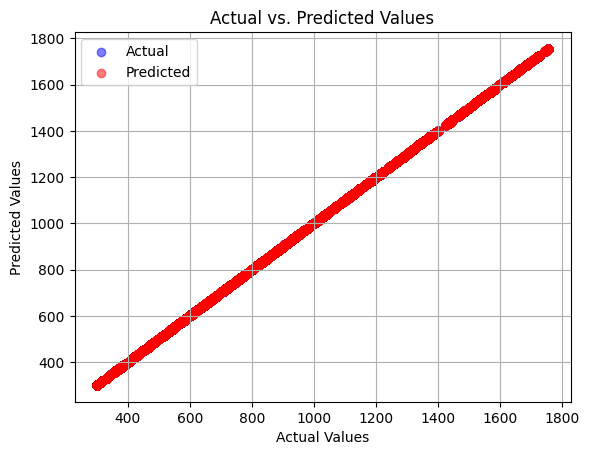

In [83]:
# Initialize the Decision Tree Regressor model
decision_tree_reg = DecisionTreeRegressor(random_state=42)

# Fit the model on the training data
decision_tree_reg.fit(X_train1, y_train1)

# Make predictions on the test data
y_pred_decision = decision_tree_reg.predict(X_test1)

# Evaluate the model
mse_dt = mean_squared_error(y_test1, y_pred_decision)
rmse_dt = mse_dt**0.5
mae_dt = mean_absolute_error(y_test1, y_pred_decision)
r2_dt = r2_score(y_test1, y_pred_decision)
adj_r2_dt = 1 - ((1 - r2_dt) * (n - 1) / (n - p - 1))

plt.scatter(y_test1, y_test1, c='b', label='Actual', alpha=0.5)  # Blue for actual
plt.scatter(y_test1, y_pred_decision, c='r', label='Predicted', alpha=0.5)  # Red for predicted
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values")
plt.legend(loc='upper left')
plt.grid(True)
plt.show()


### **Model Evaluation**

In [84]:
model = pd.DataFrame([['Decision Tree Baseline',  mse_dt,rmse_dt,mae_dt, r2_dt,adj_r2_dt]],
               columns = ['Model', 'MSE', 'RMSE', 'MAE', 'R2','adj_r2'])

model_result = pd.concat([model_result,model],axis=0,ignore_index = True)
model_result

,Model,MSE,RMSE,MAE,R2,adj_r2
0,Linear Regression Baseline,4.708514e+04,2.169911e+02,1.659218e+02,0.642670,0.642499
1,Linear Regression Tuned,4.708514e+04,2.169911e+02,1.659218e+02,0.642670,0.642499
2,Lasso Regression Baseline,4.703003e+04,2.168641e+02,1.656271e+02,0.643088,0.642917
3,Lasso Regression Tuned,4.702332e+04,2.168486e+02,1.653578e+02,0.643139,0.642968
4,Ridge Regression Baseline,4.702343e+04,2.168489e+02,1.653556e+02,0.643138,0.642967
5,Ridge Regression Tuned,4.702338e+04,2.168488e+02,1.653565e+02,0.643138,0.642968
6,Decision Tree Baseline,7.308593e-23,8.549031e-12,6.090781e-12,1.000000,1.000000


###**Hyperparameter tunning**

In [85]:
# Define hyperparameters and their potential values
param_grid_dt = {
    'criterion': ['friedman_mse', 'squared_error'],
    'max_depth': [15,30,45],
    'min_samples_split': [2,3,5],
    'max_features': [15,27,'sqrt'],
    'ccp_alpha' :[1,2]
}


# Create a GridSearchCV object for Decision Tree Regressor
grid_search_dt = GridSearchCV(decision_tree_reg, param_grid_dt, cv=3, scoring='neg_mean_squared_error')
grid_search_dt.fit(X_train1, y_train1)

# Get the best hyperparameters for Decision Tree Regressor
best_decision_tree_model = grid_search_dt.best_estimator_

In [86]:
# Print the best hyperparameters
print("Best Hyperparameters for Decision Tree:", grid_search_dt.best_estimator_)

Best Hyperparameters for Decision Tree: DecisionTreeRegressor(ccp_alpha=1, criterion='friedman_mse', max_depth=45,
                      max_features=27, random_state=42)


### **Model Evaluation**

In [87]:
# Evaluate the best model
y_pred_dt_tuned = best_decision_tree_model.predict(X_test1)

mae_dt_tuned = mean_absolute_error(y_test1, y_pred_dt_tuned)
mse_dt_tuned = mean_squared_error(y_test1, y_pred_dt_tuned)
rmse_dt_tuned = np.sqrt(mse_dt_tuned)
r2_dt_tuned = r2_score(y_test1, y_pred_dt_tuned)
adj_r2_dt_tuned = 1 - ((1 - r2_dt_tuned) * (n - 1) / (n - p - 1))

model = pd.DataFrame([['Decision Tree Tuned',  mse_dt_tuned,rmse_dt_tuned,mae_dt_tuned, r2_dt_tuned,adj_r2_dt_tuned]],
               columns = ['Model', 'MSE', 'RMSE', 'MAE', 'R2','adj_r2'])

model_result = pd.concat([model_result,model],axis=0,ignore_index = True)
model_result

,Model,MSE,RMSE,MAE,R2,adj_r2
0,Linear Regression Baseline,4.708514e+04,2.169911e+02,1.659218e+02,0.642670,0.642499
1,Linear Regression Tuned,4.708514e+04,2.169911e+02,1.659218e+02,0.642670,0.642499
2,Lasso Regression Baseline,4.703003e+04,2.168641e+02,1.656271e+02,0.643088,0.642917
3,Lasso Regression Tuned,4.702332e+04,2.168486e+02,1.653578e+02,0.643139,0.642968
4,Ridge Regression Baseline,4.702343e+04,2.168489e+02,1.653556e+02,0.643138,0.642967
5,Ridge Regression Tuned,4.702338e+04,2.168488e+02,1.653565e+02,0.643138,0.642968
6,Decision Tree Baseline,7.308593e-23,8.549031e-12,6.090781e-12,1.000000,1.000000
7,Decision Tree Tuned,4.442886e+01,6.665498e+00,4.023163e+00,0.999663,0.999663


###**Feature Importance Decision Tree**

In [88]:
# Get feature importances
feature_importances_dt_reg = best_decision_tree_model.feature_importances_

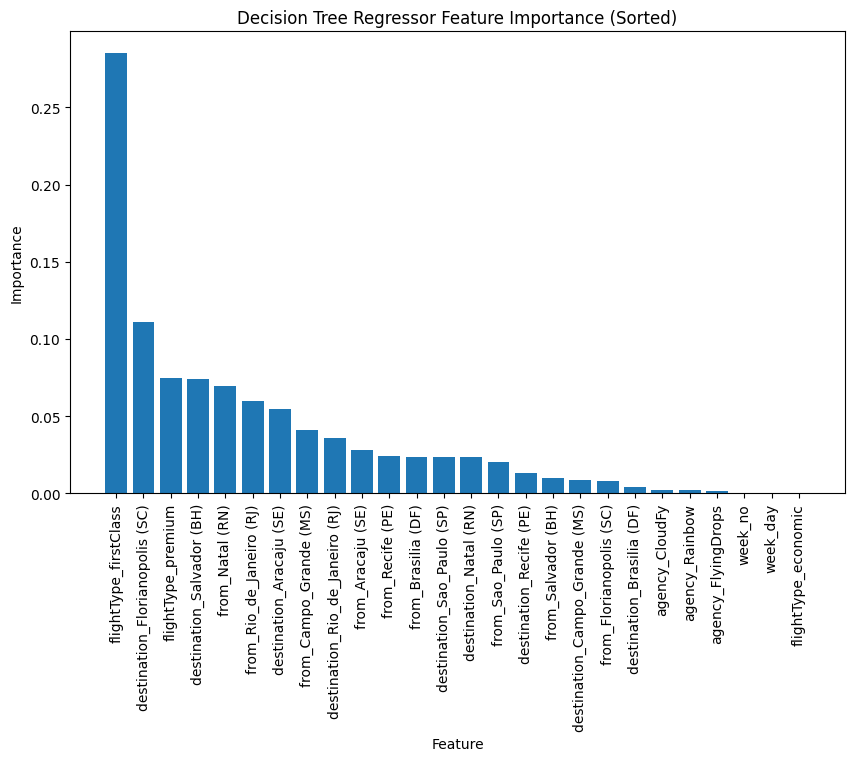

In [89]:
import matplotlib.pyplot as plt

# Define feature names
feature_names = X1.columns.tolist()  # Assuming X_train is a DataFrame

# Zip feature names and importances
feature_importances_sorted = sorted(zip(feature_names, feature_importances_dt_reg), key=lambda x: x[1], reverse=True)
sorted_features, sorted_importances = zip(*feature_importances_sorted)

# Create bar plot
plt.figure(figsize=(10, 6))
plt.bar(range(len(sorted_importances)), sorted_importances, align='center')
plt.xticks(range(len(sorted_importances)), sorted_features, rotation=90)
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('Decision Tree Regressor Feature Importance (Sorted)')
plt.show()


##**Random Forest**

###**Baseline Model**

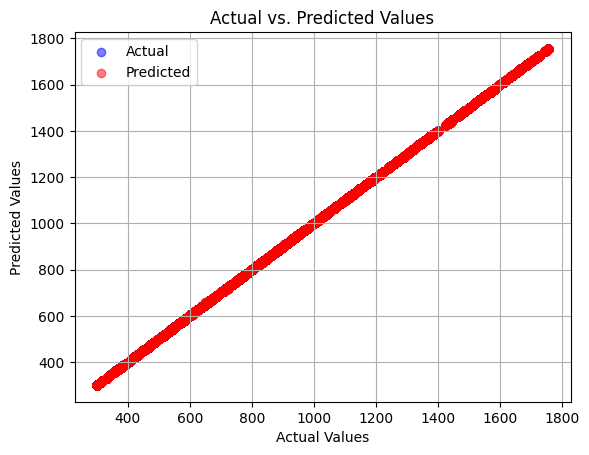

In [90]:
# Create and train the Linear Regression model
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train1, y_train1)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test1)

# Evaluate the model
mae_rf = mean_absolute_error(y_test1,y_pred_rf)
mse_rf = mean_squared_error(y_test1, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test1, y_pred_rf)
adj_r2_rf = 1 - ((1 - r2_rf) * (n - 1) / (n - p - 1))



plt.scatter(y_test1, y_test1, c='b', label='Actual', alpha=0.5)  # Blue for actual
plt.scatter(y_test1, y_pred_rf, c='r', label='Predicted', alpha=0.5)  # Red for predicted
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values")
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

### **Model Evaluation**

In [91]:
model = pd.DataFrame([['Random Forest Baseline',  mse_rf,rmse_rf,mae_rf, r2_rf,adj_r2_rf]],
               columns = ['Model', 'MSE', 'RMSE', 'MAE', 'R2','adj_r2'])

model_result = pd.concat([model_result,model],axis=0,ignore_index = True)
model_result

,Model,MSE,RMSE,MAE,R2,adj_r2
0,Linear Regression Baseline,4.708514e+04,2.169911e+02,1.659218e+02,0.642670,0.642499
1,Linear Regression Tuned,4.708514e+04,2.169911e+02,1.659218e+02,0.642670,0.642499
2,Lasso Regression Baseline,4.703003e+04,2.168641e+02,1.656271e+02,0.643088,0.642917
3,Lasso Regression Tuned,4.702332e+04,2.168486e+02,1.653578e+02,0.643139,0.642968
4,Ridge Regression Baseline,4.702343e+04,2.168489e+02,1.653556e+02,0.643138,0.642967
5,Ridge Regression Tuned,4.702338e+04,2.168488e+02,1.653565e+02,0.643138,0.642968
6,Decision Tree Baseline,7.308593e-23,8.549031e-12,6.090781e-12,1.000000,1.000000
7,Decision Tree Tuned,4.442886e+01,6.665498e+00,4.023163e+00,0.999663,0.999663
8,Random Forest Baseline,2.515837e-02,1.586139e-01,7.705278e-03,1.000000,1.000000


###**Hyperparameter tunning**

In [92]:
# Define hyperparameters and their potential values
param_grid_rf = {
    'n_estimators': [50, 100],
    'max_depth': [1,5,10],
    'min_samples_split': [2, 5,10],
    'max_features': ['sqrt',27],
    'n_jobs': [2]
}
# Create a GridSearchCV object for Random Forest Regression
grid_search_rf = GridSearchCV(rf_model, param_grid_rf, cv=3, scoring='neg_mean_squared_error')
grid_search_rf.fit(X_train1, y_train1)
# Get the best hyperparameters for Random Forest Regression
best_rf_model = grid_search_rf.best_estimator_

In [93]:
grid_search_rf.best_estimator_

RandomForestRegressor(max_depth=10, max_features='sqrt', n_jobs=2,
                      random_state=42)

In [94]:
#Print the best hyperparameters
print("Best Hyperparameters for Random Forest:", grid_search_rf.best_estimator_)

Best Hyperparameters for Random Forest: RandomForestRegressor(max_depth=10, max_features='sqrt', n_jobs=2,
                      random_state=42)





### **Model Evaluation**

In [95]:
# Evaluate the best model
y_pred_rf_tuned = best_rf_model.predict(X_test1)

mae_rf_tuned = mean_absolute_error(y_test1, y_pred_rf_tuned)
mse_rf_tuned = mean_squared_error(y_test1, y_pred_rf_tuned)
rmse_rf_tuned = np.sqrt(mse_rf_tuned)
r2_rf_tuned = r2_score(y_test1, y_pred_rf_tuned)
adj_r2_rf_tuned = 1 - ((1 - r2_rf_tuned) * (n - 1) / (n - p - 1))

model = pd.DataFrame([['Random Forest Tuned',  mse_rf_tuned,rmse_rf_tuned,mae_rf_tuned, r2_rf_tuned,adj_r2_rf_tuned]],
               columns = ['Model', 'MSE', 'RMSE', 'MAE', 'R2','adj_r2'])

model_result = pd.concat([model_result,model],axis=0,ignore_index = True)
model_result

,Model,MSE,RMSE,MAE,R2,adj_r2
0,Linear Regression Baseline,4.708514e+04,2.169911e+02,1.659218e+02,0.642670,0.642499
1,Linear Regression Tuned,4.708514e+04,2.169911e+02,1.659218e+02,0.642670,0.642499
2,Lasso Regression Baseline,4.703003e+04,2.168641e+02,1.656271e+02,0.643088,0.642917
3,Lasso Regression Tuned,4.702332e+04,2.168486e+02,1.653578e+02,0.643139,0.642968
4,Ridge Regression Baseline,4.702343e+04,2.168489e+02,1.653556e+02,0.643138,0.642967
5,Ridge Regression Tuned,4.702338e+04,2.168488e+02,1.653565e+02,0.643138,0.642968
6,Decision Tree Baseline,7.308593e-23,8.549031e-12,6.090781e-12,1.000000,1.000000
7,Decision Tree Tuned,4.442886e+01,6.665498e+00,4.023163e+00,0.999663,0.999663
8,Random Forest Baseline,2.515837e-02,1.586139e-01,7.705278e-03,1.000000,1.000000
9,Random Forest Tuned,1.780190e+04,1.334238e+02,9.954453e+01,0.864901,0.864836


###**Feature Importance Random Forest**

In [96]:
feature_importances_rf_reg = best_rf_model.feature_importances_

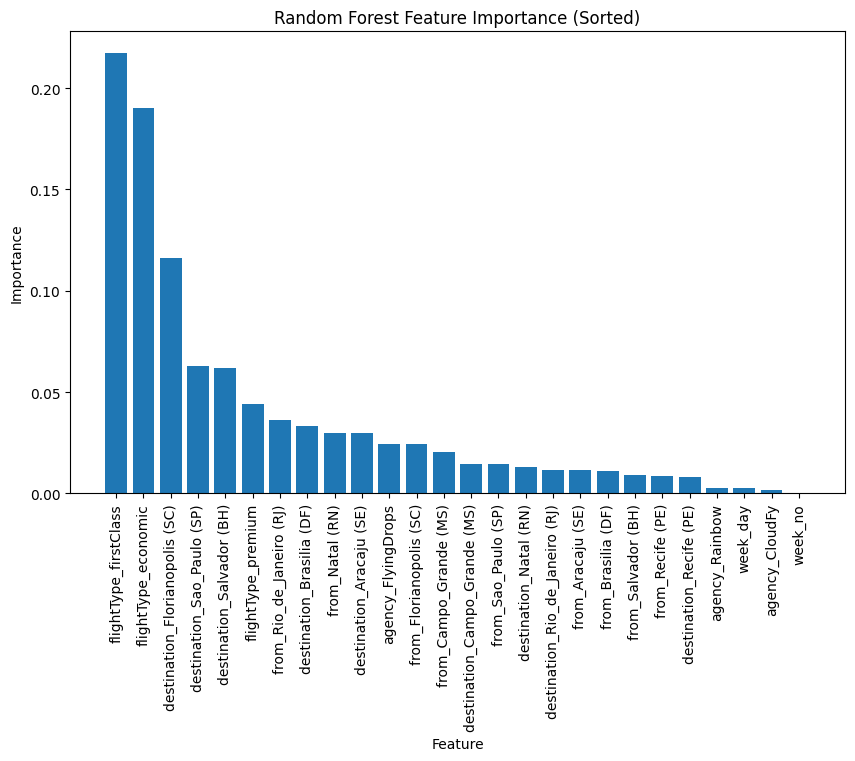

In [97]:
import matplotlib.pyplot as plt

# Define feature names
feature_names = X1.columns.tolist()  # Assuming X_train is a DataFrame

# Zip feature names and importances
feature_importances_sorted = sorted(zip(feature_names, feature_importances_rf_reg), key=lambda x: x[1], reverse=True)
sorted_features, sorted_importances = zip(*feature_importances_sorted)

# Create bar plot
plt.figure(figsize=(10, 6))
plt.bar(range(len(sorted_importances)), sorted_importances, align='center')
plt.xticks(range(len(sorted_importances)), sorted_features, rotation=90)
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('Random Forest Feature Importance (Sorted)')
plt.show()


##**XGBoost**

###**Baseline Model**

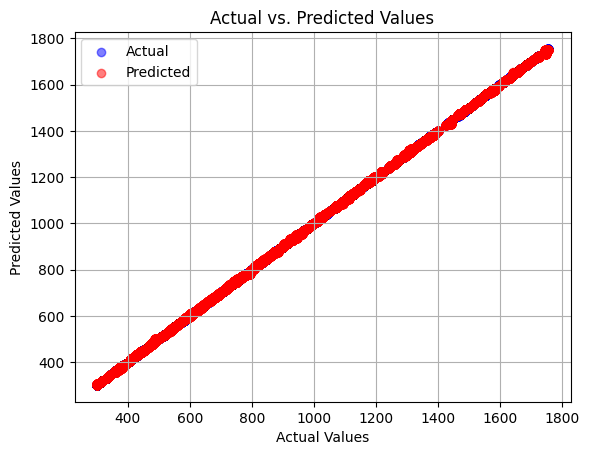

In [98]:
# Import the XGBRegressor class
from xgboost import XGBRegressor
# Define Basic XGBoost regressor
xgb_regressor_model = XGBRegressor(random_state=42)
xgb_regressor_model.fit(X_train1, y_train1)

# Evaluate the model
y_pred_xgb = xgb_regressor_model.predict(X_test1)

mae_xgb = mean_absolute_error(y_test1, y_pred_xgb)
mse_xgb = mean_squared_error(y_test1,y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test1, y_pred_xgb)
adj_r2_xgb = 1 - ((1 - r2_xgb) * (n - 1) / (n - p - 1))

plt.scatter(y_test1, y_test1, c='b', label='Actual', alpha=0.5)  # Blue for actual
plt.scatter(y_test1, y_pred_xgb, c='r', label='Predicted', alpha=0.5)  # Red for predicted
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values")
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

### **Model Evaluation**

In [99]:
model = pd.DataFrame([['XGBoost Baseline',  mse_xgb,rmse_xgb,mae_xgb, r2_xgb,adj_r2_xgb]],
               columns = ['Model', 'MSE', 'RMSE', 'MAE', 'R2','adj_r2'])

model_result = pd.concat([model_result,model],axis=0,ignore_index = True)
model_result

,Model,MSE,RMSE,MAE,R2,adj_r2
0,Linear Regression Baseline,4.708514e+04,2.169911e+02,1.659218e+02,0.642670,0.642499
1,Linear Regression Tuned,4.708514e+04,2.169911e+02,1.659218e+02,0.642670,0.642499
2,Lasso Regression Baseline,4.703003e+04,2.168641e+02,1.656271e+02,0.643088,0.642917
3,Lasso Regression Tuned,4.702332e+04,2.168486e+02,1.653578e+02,0.643139,0.642968
4,Ridge Regression Baseline,4.702343e+04,2.168489e+02,1.653556e+02,0.643138,0.642967
5,Ridge Regression Tuned,4.702338e+04,2.168488e+02,1.653565e+02,0.643138,0.642968
6,Decision Tree Baseline,7.308593e-23,8.549031e-12,6.090781e-12,1.000000,1.000000
7,Decision Tree Tuned,4.442886e+01,6.665498e+00,4.023163e+00,0.999663,0.999663
8,Random Forest Baseline,2.515837e-02,1.586139e-01,7.705278e-03,1.000000,1.000000
9,Random Forest Tuned,1.780190e+04,1.334238e+02,9.954453e+01,0.864901,0.864836


###**Hyperparameter tunning**

In [100]:
# !pip uninstall scikit-learn xgboost
# !pip install scikit-learn xgboost

In [101]:
import xgboost as xgb
import sklearn

print(f"xgboost version: {xgb.__version__}")
print(f"scikit-learn version: {sklearn.__version__}")

xgboost version: 1.6.2
scikit-learn version: 1.2.2


In [107]:
from xgboost.sklearn import XGBRegressor
param_grid = {
    'n_estimators': [3, 5],
    'max_depth': [35, 50],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'learning_rate': [0.1]
}
from sklearn.model_selection import RandomizedSearchCV

# Perform RandomizedSearchCV for hyperparameter tuning
random_search_xgb = RandomizedSearchCV(estimator=xgb_regressor_model, param_distributions=param_grid, n_iter=10, cv=3, scoring='neg_mean_squared_error', random_state=42)

# Fit the model
random_search_xgb.fit(X_train1, y_train1)

# Get the best model and parameters
best_xgb_regressor = random_search_xgb.best_estimator_
print("Best hyperparameters:", random_search_xgb.best_params_)


Best hyperparameters: {'subsample': 1.0, 'n_estimators': 5, 'max_depth': 50, 'learning_rate': 0.1, 'colsample_bytree': 1.0}


In [108]:
random_search_xgb.best_params_

{'subsample': 1.0,
 'n_estimators': 5,
 'max_depth': 50,
 'learning_rate': 0.1,
 'colsample_bytree': 1.0}

In [109]:
# Print the best hyperparameters
print("Best Hyperparameters for XGBoost Regressor:", random_search_xgb.best_params_)

Best Hyperparameters for XGBoost Regressor: {'subsample': 1.0, 'n_estimators': 5, 'max_depth': 50, 'learning_rate': 0.1, 'colsample_bytree': 1.0}


### **Model Evaluation**


In [110]:
# Evaluate the best model
y_pred_xgb_tuned = best_xgb_regressor.predict(X_test1)

mae_xgb_tuned = mean_absolute_error(y_test1, y_pred_xgb_tuned)
mse_xgb_tuned = mean_squared_error(y_test1, y_pred_xgb_tuned)
rmse_xgb_tuned = np.sqrt(mse_xgb_tuned)
r2_xgb_tuned = r2_score(y_test1, y_pred_xgb_tuned)
adj_r2_xgb_tuned = 1 - ((1 - r2_xgb_tuned) * (n - 1) / (n - p - 1))

model = pd.DataFrame([['XGBosst Model Tuned',  mse_xgb_tuned,rmse_xgb_tuned,mae_xgb_tuned, r2_xgb_tuned,adj_r2_xgb_tuned]],
               columns = ['Model', 'MSE', 'RMSE', 'MAE', 'R2','adj_r2'])

model_result = pd.concat([model_result,model],axis=0,ignore_index = True)
model_result

,Model,MSE,RMSE,MAE,R2,adj_r2
0,Linear Regression Baseline,4.708514e+04,2.169911e+02,1.659218e+02,0.642670,0.642499
1,Linear Regression Tuned,4.708514e+04,2.169911e+02,1.659218e+02,0.642670,0.642499
2,Lasso Regression Baseline,4.703003e+04,2.168641e+02,1.656271e+02,0.643088,0.642917
3,Lasso Regression Tuned,4.702332e+04,2.168486e+02,1.653578e+02,0.643139,0.642968
4,Ridge Regression Baseline,4.702343e+04,2.168489e+02,1.653556e+02,0.643138,0.642967
5,Ridge Regression Tuned,4.702338e+04,2.168488e+02,1.653565e+02,0.643138,0.642968
6,Decision Tree Baseline,7.308593e-23,8.549031e-12,6.090781e-12,1.000000,1.000000
7,Decision Tree Tuned,4.442886e+01,6.665498e+00,4.023163e+00,0.999663,0.999663
8,Random Forest Baseline,2.515837e-02,1.586139e-01,7.705278e-03,1.000000,1.000000
9,Random Forest Tuned,1.780190e+04,1.334238e+02,9.954453e+01,0.864901,0.864836


In [111]:
y_pred_rf = best_xgb_regressor.predict(X_test1)
y_pred_rf_tr = best_xgb_regressor.predict(X_train1)

In [112]:
#Training data Metrics

mse_rf_tr = mean_squared_error(y_train1, y_pred_rf_tr)
rmse_rf_tr = np.sqrt(mse_rf_tr)
mae_rf_tr = mean_absolute_error(y_train1, y_pred_rf_tr)
r2_rf_tr = r2_score(y_train1, y_pred_rf_tr)
adj_r2_rf_tr = 1 - ((1 - r2_rf_tr) * (n - 1) / (n - p - 1))

#Test data Metrics
mse_rf = mean_squared_error(y_test1, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y_test1, y_pred_rf)
r2_rf = r2_score(y_test1, y_pred_rf)
adj_r2_rf = 1 - ((1 - r2_rf) * (n - 1) / (n - p - 1))



In [113]:
print("\nRandom Forest Regression Train Metrics:")
print("Mean Squared Error (MSE):", mse_rf_tr)
print("Root Mean Squared Error (RMSE):", rmse_rf_tr)
print("Mean Absolute Error (MAE):", mae_rf_tr)
print("R-squared (R2) Score:", r2_rf_tr)
print("Adjusted R-squared (Adj R2) Score:", adj_r2_rf_tr)


print("\nRandom Forest Regression Test Metrics:")
print("Mean Squared Error (MSE):", mse_rf)
print("Root Mean Squared Error (RMSE):", rmse_rf)
print("Mean Absolute Error (MAE):", mae_rf)
print("R-squared (R2) Score:", r2_rf)
print("Adjusted R-squared (Adj R2) Score:", adj_r2_rf)



Random Forest Regression Train Metrics:
Mean Squared Error (MSE): 365425.80709011236
Root Mean Squared Error (RMSE): 604.5045964176884
Mean Absolute Error (MAE): 565.2881652177792
R-squared (R2) Score: -1.7864390819482048
Adjusted R-squared (Adj R2) Score: -1.7877720365604595

Random Forest Regression Test Metrics:
Mean Squared Error (MSE): 366075.95970113936
Root Mean Squared Error (RMSE): 605.0421139897118
Mean Absolute Error (MAE): 565.6986751340022
R-squared (R2) Score: -1.7781602170706692
Adjusted R-squared (Adj R2) Score: -1.7794892113052523


###**Feature Importance XGBoost**

In [114]:
feature_importances_xgb_reg = best_xgb_regressor.feature_importances_

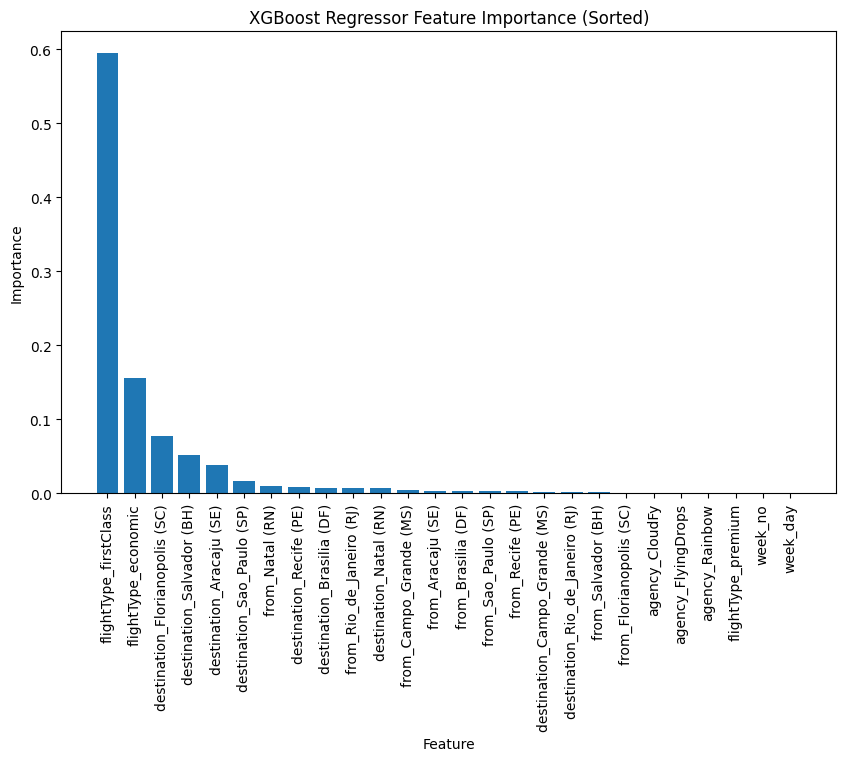

In [115]:
import matplotlib.pyplot as plt

# Define feature names
feature_names = X1.columns.tolist()  # Assuming X_train is a DataFrame

# Zip feature names and importances
feature_importances_sorted = sorted(zip(feature_names, feature_importances_xgb_reg), key=lambda x: x[1], reverse=True)
sorted_features, sorted_importances = zip(*feature_importances_sorted)

# Create bar plot
plt.figure(figsize=(10, 6))
plt.bar(range(len(sorted_importances)), sorted_importances, align='center')
plt.xticks(range(len(sorted_importances)), sorted_features, rotation=90)
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('XGBoost Regressor Feature Importance (Sorted)')
plt.show()

#**Benchmark Models**

In [116]:
#Benchmark Model on the basis on RMSE metric
model_result[model_result['RMSE']==model_result['RMSE'].min()]

,Model,MSE,RMSE,MAE,R2,adj_r2
6,Decision Tree Baseline,7.308593e-23,8.549031e-12,6.090781e-12,1.0,1.0


In [117]:
#Benchmark Model on the basis on Adjusted R2 square metric
model_result[model_result['adj_r2']==model_result['adj_r2'].max()]

,Model,MSE,RMSE,MAE,R2,adj_r2
6,Decision Tree Baseline,7.308593e-23,8.549031e-12,6.090781e-12,1.0,1.0


In [118]:
#Benchmark Models on the basis of RMSE and adjusted R2 square metrics were as follows

filtered_result = model_result[(model_result['adj_r2'] == model_result['adj_r2'].max()) | (model_result['RMSE'] == model_result['RMSE'].min())]
filtered_result

,Model,MSE,RMSE,MAE,R2,adj_r2
6,Decision Tree Baseline,7.308593e-23,8.549031e-12,6.090781e-12,1.0,1.0


Key metrics to evaluate:

**Mean Squared Error (MSE):**

Lower MSE indicates a better model.
Decision Tree Tuned has an MSE of 44.42886, which is quite low compared to other models like XGBoost Tuned (MSE = 366,076), Random Forest Tuned (MSE = 17,801), etc.

**Root Mean Squared Error (RMSE):**

RMSE is the square root of MSE, providing error in the same units as the target variable.
Decision Tree Tuned has an RMSE of 6.67, which is very small.

**Mean Absolute Error (MAE):**

MAE represents the average of the absolute errors, and lower values indicate a better model.
Decision Tree Tuned has an MAE of 4.02, which is also very low.

**R-Squared (R²):**

R² represents the proportion of variance explained by the model. A value closer to 1 is preferred.
Decision Tree Tuned has an R² of 0.999663, which is very close to 1, indicating that the model explains almost all of the variance in the data.

**Adjusted R-Squared (adj. R²):**

Adjusted R² adjusts R² for the number of predictors in the model. Higher values suggest a better fit.
Decision Tree Tuned has an adjusted R² of 0.999663, which is very close to R² and indicates an excellent fit.

**Random Forest Tuned: **
Even though it has a slightly higher error (MSE = 17,801) compared to the Decision Tree Tuned model, it is less likely to overfit because it averages predictions across multiple decision trees. This reduces the variance and makes it more robust to overfitting, especially when compared to a single decision tree.
The Random Forest Tuned model has an R² of 0.864901, which is much more reasonable, suggesting that it has better generalizability compared to the Decision Tree, which shows perfect fit.
Additionally, Random Forest models are typically more stable and perform better in terms of generalization, even if they show slightly higher error on training data, as they don't overfit as much as a single decision tree might.

**Conclusion:**

1. Overfitting in Decision Tree Tuned is a significant concern, as its perfect R² could indicate that it is memorizing the training data, rather than learning patterns that generalize well to unseen data.
2. Random Forest Tuned is likely the better choice for this case, as it provides a balance of good performance metrics (MSE, RMSE, MAE) while being less prone to overfitting compared to a single Decision Tree.
3. XGBoost Tuned, with its negative R², should likely be avoided, as it indicates a poor model fit.
4. **Random Forest Tuned** is therefore the best model when considering overfitting, as it achieves a reasonable trade-off between bias and variance and is less likely to suffer from the extreme overfitting observed with Decision Tree models.

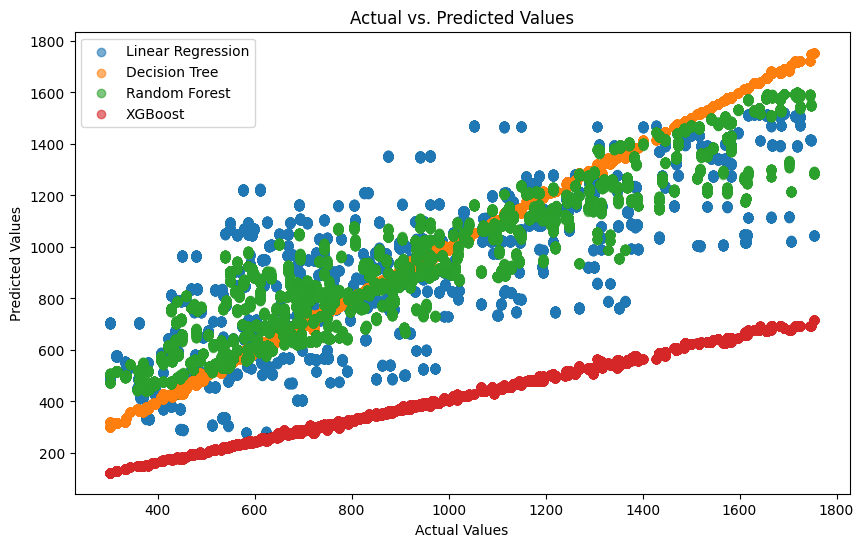

In [119]:
plt.figure(figsize=(10, 6))

# Linear Regression
plt.scatter(y_test1, y_pred_linear_tuned, label='Linear Regression', alpha=0.6)

# Lasso Regression
#plt.scatter(y_test1, y_pred_lasso_tuned, label='Lasso Regression', alpha=0.6)

# Ridge Regression
#plt.scatter(y_test1, y_pred_ridge_tuned, label='Ridge Regression', alpha=0.6)

# ElasticNet
#plt.scatter(y_test1, y_pred_elastic_tuned, label='ElasticNet', alpha=0.6)

# Decision Tree Regressor
plt.scatter(y_test1, y_pred_dt_tuned, label='Decision Tree', alpha=0.6)

# Random Forest Regressor
plt.scatter(y_test1, y_pred_rf_tuned, label='Random Forest', alpha=0.6)

# XGBoost Regressor
plt.scatter(y_test1, y_pred_xgb_tuned, label='XGBoost', alpha=0.6)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values")
plt.legend()
plt.show()


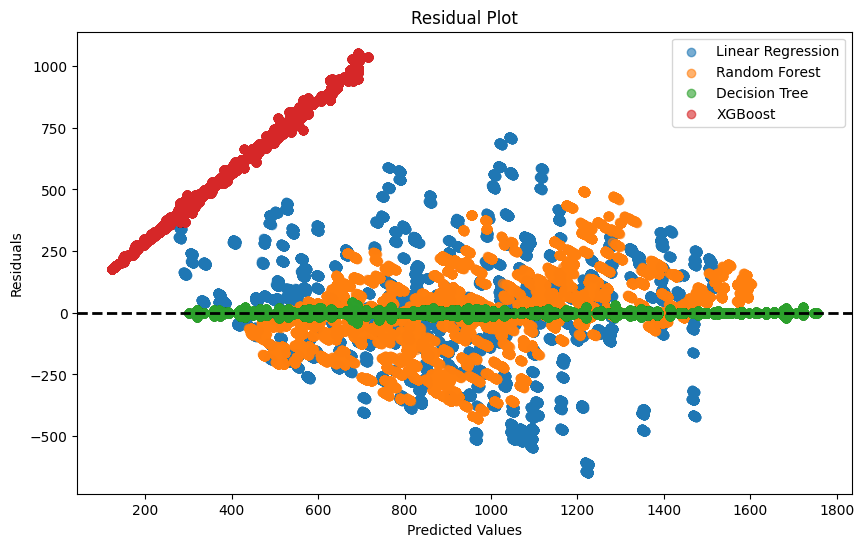

In [120]:
plt.figure(figsize=(10, 6))

# Linear Regression Residuals
residuals_lr = y_test1 - y_pred_linear_tuned
plt.scatter(y_pred_linear_tuned, residuals_lr, label='Linear Regression', alpha=0.6)

# Random Forest Regressor Residuals
residuals_rf = y_test1 - y_pred_rf_tuned
plt.scatter(y_pred_rf_tuned, residuals_rf, label='Random Forest', alpha=0.6)

# Decision Tree Regressor Residuals
residuals_dt = y_test1 -y_pred_dt_tuned
plt.scatter(y_pred_dt_tuned, residuals_dt, label='Decision Tree', alpha=0.6)

# XGBoost Regressor Residuals
residuals_xgb = y_test1 -y_pred_xgb_tuned
plt.scatter(y_pred_xgb_tuned, residuals_xgb, label='XGBoost', alpha=0.6)

plt.axhline(0, color='black', linestyle='--', lw=2)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.legend()
plt.show()

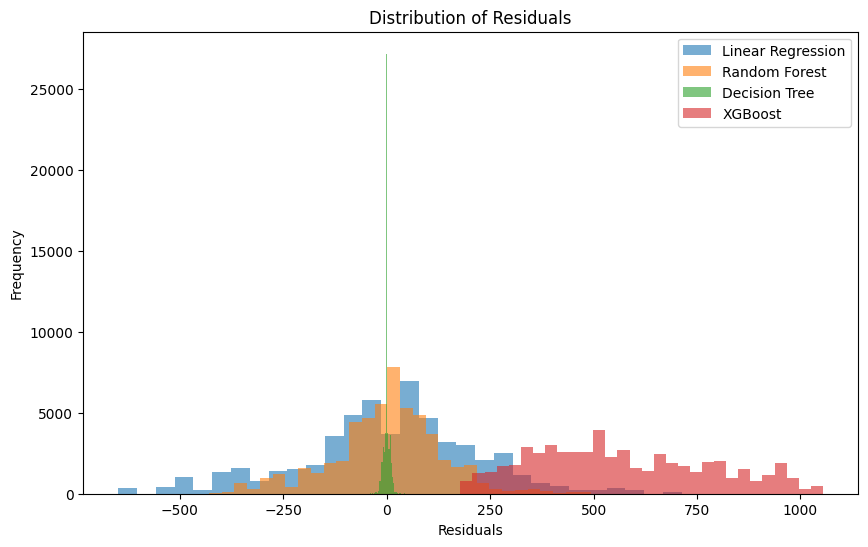

In [121]:
plt.figure(figsize=(10, 6))

# Linear Regression Residuals Distribution
plt.hist(residuals_lr, bins=30, alpha=0.6, label='Linear Regression')

# Random Forest Regressor Residuals Distribution
plt.hist(residuals_rf, bins=30, alpha=0.6, label='Random Forest')

# Decision Tree Regressor Residuals Distribution
plt.hist(residuals_dt, bins=30, alpha=0.6, label='Decision Tree')

# XGBoost Regressor Residuals Distribution
plt.hist(residuals_xgb, bins=30, alpha=0.6, label='XGBoost')

plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")
plt.legend()
plt.show()

##**Feature Selection Using Multicollinearity and Vif Score**

In [122]:
#Multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor
def calc_vif(X):

    # Calculating VIF
    vif = pd.DataFrame()
    vif["variables"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

    return(vif)


In [123]:
final_df= flights_filtered.drop(columns=['flight_speed','time','month','year','distance'],axis=1)

In [124]:
# Select only numeric columns
numeric_df = final_df.select_dtypes(include=[float, int])

# Calculate the correlation matrix using only numeric columns
correlation_matrix = numeric_df.corr()
k = 27  # Replace with the desired number of top features
selected_features = correlation_matrix['price'].abs().sort_values(ascending=False).index[1:k+1]


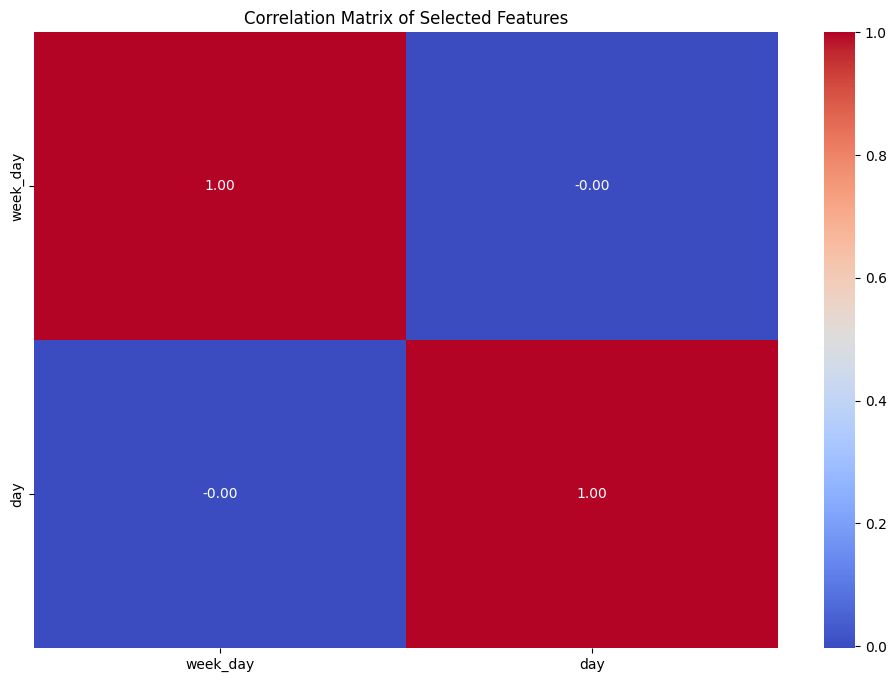

In [125]:
# Create a subset of the DataFrame with the selected features
subset_df = final_df[selected_features]

# Calculate the correlation matrix for the selected features
correlation_matrix = subset_df.corr()

# Set up the plot figure size
plt.figure(figsize=(12, 8))

# Create a heatmap of the correlation matrix
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")

# Set the plot title
plt.title('Correlation Matrix of Selected Features')

# Show the plot
plt.show()

In [126]:
calc_vif(flights_filtered[[i for i in flights_filtered.describe().columns if i  in selected_features]])

,variables,VIF
0,week_day,2.584125
1,day,2.584125


# **Flask Building**

Things we need to do:

**Flask Web Application**: We create a Flask web application to serve as an API endpoint.

**Load Trained Model**: We load a trained regression model (you should replace this with your actual model loading code).

**Prediction Function**: We define a function (predict_value) to make predictions using the loaded model.

**User Input Processing**: In the /predict route, we collect user input data from an HTML form, including price, travel details, and other parameters.

**Data Preparation**: We prepare the user input data and convert it into a format suitable for making predictions.

**Prediction**: Using the loaded model, we make predictions based on the user's input.

**JSON Response**: We return the prediction result as a JSON response to the API request.

**HTML Form**: If the request is a GET request, we display an HTML form to collect user input.

**Styling**: You can customize the HTML form and add CSS styling to make it visually appealing.

**Run the Flask App**: The Flask app is run, allowing users to access it and receive predictions through API requests.

In [127]:
import pickle
pickle.dump(scaler_new,open('/content/drive/MyDrive/travel_capstone/scaling.pkl','wb'))
pickle.dump(best_rf_model,open('/content/drive/MyDrive/travel_capstone/rf_model.pkl','wb'))

In [128]:
pickle.dump(best_linear_reg,open('/content/drive/MyDrive/travel_capstone/lr_model.pkl','wb'))
pickle.dump(best_lasso_model,open('/content/drive/MyDrive/travel_capstone/lasso_model.pkl','wb'))
pickle.dump(best_ridge_model,open('/content/drive/MyDrive/travel_capstone/ridge_model.pkl','wb'))
pickle.dump(best_decision_tree_model,open('/content/drive/MyDrive/travel_capstone/dt_model.pkl','wb'))
pickle.dump(best_xgb_regressor,open('/content/drive/MyDrive/travel_capstone/xgb_model.pkl','wb'))

In [129]:
with open("/content/drive/MyDrive/travel_capstone/scaling.pkl", "wb") as f:
    pickle.dump(scaler_new, f)

In [130]:
scaler_model=pickle.load(open('/content/drive/MyDrive/travel_capstone/scaling.pkl','rb'))
xgb_model=pickle.load(open('/content/drive/MyDrive/travel_capstone/xgb_model.pkl','rb'))

In [132]:
# Create a function for prediction
def predict_price(input_data, model,scaler):
    # Prepare the input data

    # Initialize an empty DataFrame
    df_input2 = pd.DataFrame([input_data])

    # Independent features
    X = df_input2

    # Scale the data using the same scaler used during training
    X = scaler.transform(X)

    # Make predictions using the trained Decision model
    y_pred = model.predict(X)

    return y_pred[0]

##**Testing Pickled model**

In [133]:
df_input = pd.read_csv('/content/drive/MyDrive/travel_capstone/flights.csv',on_bad_lines='skip')


df_input['date'] = pd.to_datetime(df_input['date'])
df_input['day'] = df_input['date'].dt.day
df_input['date'] = pd.to_datetime(df_input['date'])
df_input['week_no'] = df_input['date'].dt.isocalendar().week
df_input['week_day'] = df_input['date'].dt.weekday
df_input['month'] = df_input['date'].dt.month
df_input['year'] = df_input['date'].dt.year
df_input['flight_speed'] = df_input['distance']/df_input['time']  # Add flight_speed appropriately


# renaming the Column name
df_input.rename(columns={"to":"destination"},inplace=True)

# one-hot encoding
df_input = pd.get_dummies(df_input, columns=['from','destination','flightType','agency'])

# renaming the Column name
df_input.rename(columns={'from_Sao Paulo (SP)':'from_Sao_Paulo (SP)','from_Rio de Janeiro (RJ)':'from_Rio_de_Janeiro (RJ)','from_Campo Grande (MS)':'from_Campo_Grande (MS)',
                                  'destination_Sao Paulo (SP)':'destination_Sao_Paulo (SP)','destination_Rio de Janeiro (RJ)':'destination_Rio_de_Janeiro (RJ)','destination_Campo Grande (MS)':'destination_Campo_Grande (MS)'},inplace=True)




In [134]:
df_input

,travelCode,userCode,price,time,distance,date,day,week_no,week_day,month,...,destination_Recife (PE),destination_Rio_de_Janeiro (RJ),destination_Salvador (BH),destination_Sao_Paulo (SP),flightType_economic,flightType_firstClass,flightType_premium,agency_CloudFy,agency_FlyingDrops,agency_Rainbow
0,0,0,1434.38,1.76,676.53,2019-09-26,26,39,3,9,...,False,False,False,False,False,True,False,False,True,False
1,0,0,1292.29,1.76,676.53,2019-09-30,30,40,0,9,...,True,False,False,False,False,True,False,False,True,False
2,1,0,1487.52,1.66,637.56,2019-10-03,3,40,3,10,...,False,False,False,False,False,True,False,True,False,False
3,1,0,1127.36,1.66,637.56,2019-10-04,4,40,4,10,...,False,False,False,False,False,True,False,True,False,False
4,2,0,1684.05,2.16,830.86,2019-10-10,10,41,3,10,...,False,False,True,False,False,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271883,135941,1339,1446.34,1.49,573.81,2020-07-12,12,28,6,7,...,False,False,False,False,False,True,False,True,False,False
271884,135942,1339,726.95,1.84,709.37,2020-07-16,16,29,3,7,...,False,False,False,False,True,False,False,True,False,False
271885,135942,1339,873.07,1.84,709.37,2020-07-20,20,30,0,7,...,False,False,False,False,True,False,False,True,False,False
271886,135943,1339,313.62,1.21,466.30,2020-07-23,23,30,3,7,...,False,True,False,False,True,False,False,True,False,False


Y=df_input.loc[:,['from_Florianopolis (SC)',
 'from_Sao_Paulo (SP)',
 'from_Salvador (BH)',
 'from_Brasilia (DF)',
 'from_Rio_de_Janeiro (RJ)',
 'from_Campo_Grande (MS)',
 'from_Aracaju (SE)',
 'from_Natal (RN)',
 'from_Recife (PE)',
 'destination_Florianopolis (SC)',
 'destination_Sao_Paulo (SP)',
 'destination_Salvador (BH)',
 'destination_Brasilia (DF)',
 'destination_Rio_de_Janeiro (RJ)',
 'destination_Campo_Grande (MS)',
 'destination_Aracaju (SE)',
 'destination_Natal (RN)',
 'destination_Recife (PE)',
 'flightType_economic',
 'flightType_firstClass',
 'flightType_premium',
 'agency_Rainbow',
 'agency_CloudFy',
 'agency_FlyingDrops',
 'week_no',
 'week_day',
 'day']]

In [135]:
#ordering features based on requirement
Z=df_input[X1.columns]

In [136]:
#Edited Code
row_index = 10  # Replace with the desired row index

# Access the row from df_input using iloc
input_row = Z.iloc[row_index]

# Create an input dictionary from the selected row
input_data = Z.iloc[row_index].to_dict()
#scaler_model_new1=pickle.load(open('/content/drive/MyDrive/travel_capstone/scaler_new','rb'))
#rf_model_new1=pickle.load(open('/content/drive/MyDrive/travel_capstone/dt_model_new','rb'))
predicted_price = str(round(predict_price(input_data, best_rf_model,scaler_model),2))
print(f'Predicted Flight Price Per Person: ${predicted_price}')

Predicted Flight Price Per Person: $1272.35


#**Flask Code**

In [ ]:
#Final Flask Code
# Create a function for prediction
import pandas as pd
import pickle
from flask import Flask, request, jsonify

from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


def predict_price(input_data, model, scaler):
    # Prepare the input data

    # Initialize an empty DataFrame
    df_input2 = pd.DataFrame([input_data])

    # Independent features
    X = df_input2

    # Scale the data using the same scaler used during training
    X = scaler.transform(X)

    # Make predictions using the trained Decision model
    y_prediction = model.predict(X)

    return y_prediction[0]


app = Flask(__name__)


@app.route('/',
           methods=['GET', 'POST'])
def predict():
    return """

<!DOCTYPE html>
<html>
  <head>
    <title>Flight Price Prediction</title>
    <style>
      body {
        font-family: 'Poppins', sans-serif;
        background-color: #f9f9f9;
        margin: 0;
        padding: 0;
      }

      .container {
        max-width: 800px;
        margin: 0 auto;
        padding: 40px;
        background-color: #ffffff;
        border-radius: 10px;
        box-shadow: 0 10px 20px rgba(0, 0, 0, 0.1);
        text-align: center;
      }

      h1 {
        color: #007BFF;
        font-size: 36px;
        margin-bottom: 20px;
      }

      form {
        text-align: left;
      }

      input[type="text"],
      input[type="number"] {
        width: 100%;
        padding: 15px;
        margin: 15px 0;
        border: none;
        border-bottom: 2px solid #007BFF;
        font-size: 18px;
        background-color: transparent;
        color: #333;
        transition: border-bottom 0.3s ease;
      }

      input[type="text"]:focus,
      input[type="number"]:focus {
        border-bottom: 2px solid #0056b3;
        outline: none;
      }

      input[type="checkbox"],
      input[type="radio"] {
        margin-right: 10px;
      }

      input[type="submit"] {
        background-color: #007BFF;
        color: #fff;
        padding: 15px 30px;
        border: none;
        border-radius: 5px;
        cursor: pointer;
        font-size: 20px;
        transition: background-color 0.3s ease;
      }

      input[type="submit"]:hover {
        background-color: #0056b3;
      }

      p#prediction {
        margin-top: 20px;
        font-size: 24px;
        color: #007BFF;
      }
    </style>
  </head>
  <body>
    <div class="container">
      <h1>Flight Price Prediction</h1>
      <form action="/predict" method="POST">
        <b>Select a Boarding City</b>
        <br />
        <br />
        <input type="radio" id="Aracaju" name="from" value="Aracaju">
        <label for="Aracaju">Aracaju</label>
        <br>
        <input type="radio" id="Brasilia" name="from" value="Brasilia">
        <label for="Brasilia">Brasilia</label>
        <br>
        <input type="radio" id="Campo" name="from" value="Campo_Grande">
        <label for="Campo_Grande">Campo_Grande</label>
        <br>
        <input type="radio" id="Florianopolis" name="from" value="Florianopolis">
        <label for="Florianopolis">Florianopolis</label>
        <br>
        <input type="radio" id="Natal" name="from" value="Natal">
        <label for="Natal">Natal</label>
        <br>
        <input type="radio" id="Recife" name="from" value="Recife">
        <label for="Recife">Recife</label>
        <br>
        <input type="radio" id="Rio_de_Janeiro" name="from" value="Rio_de_Janeiro">
        <label for="Rio_de_Janeiro">Rio_de_Janeiro</label>
        <br>
        <input type="radio" id="Salvador" name="from" value="Salvador">
        <label for="Salvador">Salvador</label>
        <br>
        <input type="radio" id="Sao_Paulo" name="from" value="Sao_Paulo">
        <label for="Sao_Paulo">Sao_Paulo</label>
        <br>
        <br />
        <br />
        <b>Select a Destination City</b>
        <br />
        <br />
        <input type="radio" id="Aracaju" name="Destination" value="Aracaju">
        <label for="Aracaju">Aracaju</label>
        <br>
        <input type="radio" id="Brasilia" name="Destination" value="Brasilia">
        <label for="Brasilia">Brasilia</label>
        <br>
        <input type="radio" id="Campo_Grande" name="Destination" value="Campo_Grande">
        <label for="Campo">Campo_Grande</label>
        <br>
        <input type="radio" id="Florianopolis" name="Destination" value="Florianopolis">
        <label for="Florianopolis">Florianopolis</label>
        <br>
        <input type="radio" id="Natal" name="Destination" value="Natal">
        <label for="Natal">Natal</label>
        <br>
        <input type="radio" id="Recife" name="Destination" value="Recife">
        <label for="Recife">Recife</label>
        <br>
        <input type="radio" id="Rio_de_Janeiro" name="Destination" value="Rio_de_Janeiro">
        <label for="Rio_de_Janeiro">Rio_de_Janeiro</label>
        <br>
        <input type="radio" id="Salvador" name="Destination" value="Salvador">
        <label for="Salvador">Salvador</label>
        <br>
        <input type="radio" id="Sao_Paulo" name="Destination" value="Sao_Paulo">
        <label for="Sao_Paulo">Sao_Paulo</label>
        <br>
        <br />
        <br />
        <b>Select a Flight Type</b>
        <br />
        <br />
        <input type="radio" id="flightType_premium" name="flightType" value="premium">
        <label for="flightType_premium">premium</label>
        <br>
        <input type="radio" id="flightType_economic" name="flightType" value="economic">
        <label for="flightType_economic">economic</label>
        <br>
        <input type="radio" id="flightType_firstClass" name="flightType" value="firstClass">
        <label for="flightType_firstClass">firstClass</label>
        <br />
        <br />
        <b>Select Agency</b>
        <br />
        <br />
        <input type="radio" id="FlyingDrops" name="agency" value="FlyingDrops">
        <label for="FlyingDrops">FlyingDrops</label>
        <br>
        <input type="radio" id="Rainbow" name="agency" value="Rainbow">
        <label for="Rainbow">Rainbow</label>
        <br>
        <input type="radio" id="CloudFy" name="agency" value="CloudFy">
        <label for="CloudFy">CloudFy</label>
        <br />
        <br />
        <label for="day">day:</label>
        <input type="number" name="day" min="1" max="31" placeholder="Travel day" value="5">
        <label for="week_no">week_no:</label>
        <input type="number" name="week_no" min="1" max="53" placeholder="Travel Week No" value="7">
        <label for="week_day">week_day No :</label>
        <input type="number" name="week_day" min="1" max="7" placeholder="Travel Week Day" value="5">
        <input type="submit" value="Predict">
      </form>
      <p id="prediction"></p>
    </div>
  </body>
</html>







    """


@app.route('/predict', methods=['POST'])
def index():
    if request.method == 'POST':
        # Get input data from the form
        boarding = str(request.form.get('from'))
        destination = str(request.form.get('Destination'))
        selected_flight_class = str(request.form.get('flightType'))
        selected_agency = str(request.form.get('agency'))
        week_no = int(request.form.get('week_no'))
        week_day = int(request.form.get('week_day'))
        day = int(request.form.get('day'))

        boarding = 'from_' + boarding
        boarding_city_list = ['from_Florianopolis (SC)',
                              'from_Sao_Paulo (SP)',
                              'from_Salvador (BH)',
                              'from_Brasilia (DF)',
                              'from_Rio_de_Janeiro (RJ)',
                              'from_Campo_Grande (MS)',
                              'from_Aracaju (SE)',
                              'from_Natal (RN)',
                              'from_Recife (PE)']

        destination = 'destination_' + destination
        destination_city_list = ['destination_Florianopolis (SC)',
                                 'destination_Sao_Paulo (SP)',
                                 'destination_Salvador (BH)',
                                 'destination_Brasilia (DF)',
                                 'destination_Rio_de_Janeiro (RJ)',
                                 'destination_Campo_Grande (MS)',
                                 'destination_Aracaju (SE)',
                                 'destination_Natal (RN)',
                                 'destination_Recife (PE)']

        selected_flight_class = 'flightType_' + selected_flight_class
        class_list = ['flightType_economic',
                      'flightType_firstClass',
                      'flightType_premium']

        selected_agency = 'agency_' + selected_agency
        agency_list = ['agency_Rainbow',
                       'agency_CloudFy',
                       'agency_FlyingDrops']

        travel_dict = dict()

        for city in boarding_city_list:
            if city[:-5] != boarding:
                travel_dict[city] = 0
            else:
                travel_dict[city] = 1
        for city in destination_city_list:
            if city[:-5] != destination:
                travel_dict[city] = 0
            else:
                travel_dict[city] = 1
        for flight_class in class_list:
            if flight_class != selected_flight_class:
                travel_dict[flight_class] = 0
            else:
                travel_dict[selected_flight_class] = 1
        for agency in agency_list:
            if agency != selected_agency:
                travel_dict[agency] = 0
            else:
                travel_dict[selected_agency] = 1
        travel_dict['week_no'] = week_no
        travel_dict['week_day'] = week_day
        travel_dict['day'] = day

        scaler_model_new=pickle.load(open('/content/drive/MyDrive/travel_capstone/scaling','rb'))
        rf_model_new=pickle.load(open('/content/drive/MyDrive/travel_capstone/rf_model','rb'))
        # Perform prediction using the custom_input dictionary
        predicted_price = str(round(predict_price(travel_dict, rf_model, scaler_model), 2))
        # print(f'Predicted Flight Price Per Person: ${predicted_price}')

        return jsonify({'prediction': predicted_price})


if __name__ == '__main__':
    app.run(debug=True,host="0.0.0.0", port=8001)


 * Serving Flask app '__main__'
 * Debug mode: on


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:8001
 * Running on http://172.28.0.12:8001
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug: * Restarting with stat
